# ViT-Tiny — Cross-Database Deepfake Detection Experiment

**Research question:** Does a Vision Transformer trained on one deepfake dataset generalize to others?

**Why ViT as the third model?**  
CNN-SRM captures local noise patterns; EfficientNetB0 captures local semantic texture.  
ViT uses **global self-attention across image patches** — a fundamentally different inductive bias  
with no convolution. It asks: *are there globally inconsistent relationships between distant regions?*

**Architecture (ViT-Tiny, pure Keras, no external dependencies):**
- Input: 224×224×3 → 196 patches of 16×16
- Patch embedding: Conv2D stride-16 → (B, 196, 192)
- Learnable positional embeddings
- 6× Transformer encoder blocks (LayerNorm → MHSA → Add → LayerNorm → MLP → Add)
- Global average pooling → Dense head → sigmoid
- ~2.9M parameters — safe for Tesla T4

**Training strategy:** Single-phase end-to-end training from random init (no pre-trained weights).  
AdamW (lr=1e-4, weight_decay=0.05), no label smoothing, dropout=0.30, class_weight={FAKE:3×} to prevent all-REAL collapse.

In [1]:
# =================== CELL 1: SETUP ===================
import os
import gc
import random
import pickle
import numpy as np
import tensorflow as tf
from datetime import datetime

os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices=false'
os.environ['XLA_FLAGS'] = '--xla_gpu_cuda_data_dir=/usr/lib/nvidia-cuda-toolkit'
tf.config.optimizer.set_jit(False)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print('✅ GPU memory growth enabled')
    except RuntimeError as e:
        print(e)

tf.keras.backend.clear_session()
print(f'✅ Setup complete — TensorFlow {tf.__version__}')

2026-06-09 08:49:29.498217: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✅ GPU memory growth enabled
✅ Setup complete — TensorFlow 2.20.0


In [2]:
# =================== CELL 2: PATHS & TENSORBOARD CONFIG ===================

GDRIVE_PATH   = os.path.expanduser('~/RealEyes/gdrive')
DATASET_ROOT  = os.path.join(GDRIVE_PATH, 'data_set_split')
DATASETS_DIR  = os.path.expanduser('~/RealEyes/RealEyes/datasets')
CELEBDF_DIR   = os.path.join(DATASETS_DIR, 'celebdf_v2')

MODEL_NAME            = 'vit'
EXPERIMENT_MODELS_DIR = os.path.join(GDRIVE_PATH, 'deepfake_image_project', 'models', 'RealEyes_experiment')
MODEL_DIR             = os.path.join(EXPERIMENT_MODELS_DIR, MODEL_NAME)
os.makedirs(MODEL_DIR, exist_ok=True)

TB_LOG_ROOT = os.path.expanduser('~/RealEyes/tensorboard_logs')
os.makedirs(TB_LOG_ROOT, exist_ok=True)


def get_tb_log_dir(train_db_name, suffix='train'):
    ts = datetime.now().strftime('%Y%m%d_%H%M')
    return os.path.join(TB_LOG_ROOT, MODEL_NAME, f'{suffix}_{train_db_name}', ts)


def log_eval_to_tb(train_db_name, test_db_name, metrics: dict, step=0):
    log_dir = os.path.join(
        TB_LOG_ROOT, MODEL_NAME, 'cross_db_eval',
        f'train_{train_db_name}__test_{test_db_name}'
    )
    writer = tf.summary.create_file_writer(log_dir)
    with writer.as_default():
        for name, value in metrics.items():
            tf.summary.scalar(name, float(value), step=step)
    writer.flush()


print('✅ Paths ready')
print(f'  MODEL_DIR  : {MODEL_DIR}')
print(f'  TB_LOG_ROOT: {TB_LOG_ROOT}')
print()
print('▶  View TensorBoard:')
print(f'  [server ] tensorboard --logdir {TB_LOG_ROOT} --port 6006 --bind_all')
print( '  [local  ] ssh -L 6006:localhost:6006 <user>@<server_ip>')
print( '  [browser] http://localhost:6006')

✅ Paths ready
  MODEL_DIR  : /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/vit
  TB_LOG_ROOT: /home/sceuser/RealEyes/tensorboard_logs

▶  View TensorBoard:
  [server ] tensorboard --logdir /home/sceuser/RealEyes/tensorboard_logs --port 6006 --bind_all
  [local  ] ssh -L 6006:localhost:6006 <user>@<server_ip>
  [browser] http://localhost:6006


In [3]:
# =================== CELL 3: DATABASE DEFINITIONS ===================

DATABASES = {}


def _try_add(name, paths):
    missing = [k for k, v in paths.items() if not os.path.isdir(v)]
    if missing:
        print(f'  ⚠️  {name}: missing splits {missing} — skipped')
        return
    DATABASES[name] = paths
    print(f'  ✅ {name}')


print('🗂  Scanning databases...')

_try_add('OpenForensics', {
    'train': os.path.join(DATASETS_DIR, 'OpenForensicsV1/Dataset/Train'),
    'val':   os.path.join(DATASETS_DIR, 'OpenForensicsV1/Dataset/Validation'),
    'test':  os.path.join(DATASETS_DIR, 'OpenForensicsV1/Dataset/Test'),
})
_try_add('CustomWar', {
    'train': os.path.join(DATASET_ROOT, 'train'),
    'val':   os.path.join(DATASET_ROOT, 'val'),
    'test':  os.path.join(DATASET_ROOT, 'test'),
})
_try_add('CelebDF', {
    'train': os.path.join(CELEBDF_DIR, 'train'),
    'val':   os.path.join(CELEBDF_DIR, 'val'),
    'test':  os.path.join(CELEBDF_DIR, 'test'),
})
_try_add('CiFake', {
    'train': os.path.join(DATASETS_DIR, 'cifake_split', 'train'),
    'val':   os.path.join(DATASETS_DIR, 'cifake_split', 'val'),
    'test':  os.path.join(DATASETS_DIR, 'cifake_split', 'test'),
})

print(f'\n📋 Active databases: {list(DATABASES.keys())}')

🗂  Scanning databases...
  ✅ OpenForensics
  ✅ CustomWar
  ✅ CelebDF
  ✅ CiFake

📋 Active databases: ['OpenForensics', 'CustomWar', 'CelebDF', 'CiFake']


In [4]:
# =================== CELL 4: DATA LOADING HELPERS ===================

def load_dataset_images(dataset_path, max_images=None):
    valid_ext = {'.jpg', '.jpeg', '.png', '.gif', '.bmp'}
    image_paths, labels, skipped = [], [], 0

    for folder in sorted(os.listdir(dataset_path)):
        fpath = os.path.join(dataset_path, folder)
        if not os.path.isdir(fpath):
            continue
        fu = folder.upper()
        if fu == 'FAKE':
            label = 1
        elif fu == 'REAL':
            label = 0
        else:
            print(f'  ⚠️  Unknown folder "{folder}" — skipped')
            continue

        collected = []
        for root, _, files in os.walk(fpath):
            for fname in files:
                if os.path.splitext(fname)[1].lower() not in valid_ext:
                    skipped += 1
                    continue
                collected.append(os.path.join(root, fname))
        if max_images:
            collected = collected[:max_images]
        image_paths.extend(collected)
        labels.extend([label] * len(collected))

    if skipped:
        print(f'  ⚠️  {skipped} non-image files skipped')
    return np.array(image_paths), np.array(labels)


def load_db_split(db_name, split='train'):
    """Load (paths, labels) for a specific database and split.

    Uses cifake_split/{train,val,test} — a proper 3-way split with no leakage.
    """
    paths, labels = load_dataset_images(DATABASES[db_name][split])
    n_real = int(np.sum(labels == 0))
    n_fake = int(np.sum(labels == 1))
    print(f'    {db_name}/{split}: {len(paths):,} images  (REAL={n_real:,}, FAKE={n_fake:,})')
    return paths, labels


def compute_class_weights(labels):
    from sklearn.utils.class_weight import compute_class_weight
    classes = np.unique(labels)
    weights = compute_class_weight('balanced', classes=classes, y=labels)
    return {int(c): float(w) for c, w in zip(classes, weights)}


print('✅ Data loading helpers ready')

✅ Data loading helpers ready


In [5]:
# =================== CELL 5: VIT DATASET PIPELINE ===================
# ViT trains from scratch → normalize to [0, 1], no ImageNet preprocessing.
# Stronger augmentation to compensate for no pre-training.

IMG_SIZE = (224, 224)
AUTOTUNE = tf.data.AUTOTUNE


def _decode_normalize(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, tf.cast(label, tf.float32)


def _augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.12)
    img = tf.image.random_contrast(img, lower=0.85, upper=1.15)
    img = tf.image.random_saturation(img, lower=0.85, upper=1.15)
    # Random 90° rotation — patch-based model is rotation-equivariant
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    img = tf.image.rot90(img, k)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label


def build_vit_dataset(image_paths, labels, batch_size=32, training=False):
    ds = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    if training:
        ds = ds.shuffle(min(len(image_paths), 10000), reshuffle_each_iteration=True)
    ds = ds.map(_decode_normalize, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(_augment, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


print('✅ ViT dataset pipeline ready')

✅ ViT dataset pipeline ready


In [6]:
# =================== CELL 6: COMBINED DATASET HELPERS ===================
# Used for:
#   - build_combined_train_dataset : equal-weight sampling from all 4 databases
#   - build_combined_val_dataset   : pooled val splits (no augment)
#   - build_combined_test_dataset  : pooled test splits (no augment)
# All three functions mirror the same preprocessing as build_vit_dataset.
# ─────────────────────────────────────────────────────────────────────────

def build_combined_train_dataset(batch_size=32):
    """Sample equally from all 4 training databases using sample_from_datasets."""
    per_db_ds = []
    for db_name in DATABASES:
        paths, labels = load_db_split(db_name, 'train')
        ds = tf.data.Dataset.from_tensor_slices((paths, labels))
        ds = ds.shuffle(min(len(paths), 10_000), seed=42, reshuffle_each_iteration=True)
        per_db_ds.append(ds)
    weights = [1.0 / len(per_db_ds)] * len(per_db_ds)
    combined = tf.data.Dataset.sample_from_datasets(per_db_ds, weights=weights, seed=42)
    combined = combined.map(_decode_normalize, num_parallel_calls=AUTOTUNE)
    combined = combined.map(_augment,          num_parallel_calls=AUTOTUNE)
    combined = combined.batch(batch_size).prefetch(AUTOTUNE)
    return combined


def build_combined_val_dataset(batch_size=32):
    """Pool val splits from all 4 databases (no augmentation)."""
    all_paths, all_labels = [], []
    for db_name in DATABASES:
        p, l = load_db_split(db_name, 'val')
        all_paths.extend(p); all_labels.extend(l)
    return build_vit_dataset(
        np.array(all_paths), np.array(all_labels),
        batch_size=batch_size, training=False
    )


def build_combined_test_dataset(batch_size=32):
    """Pool test splits from all 4 databases (no augmentation)."""
    all_paths, all_labels = [], []
    for db_name in DATABASES:
        p, l = load_db_split(db_name, 'test')
        all_paths.extend(p); all_labels.extend(l)
    return build_vit_dataset(
        np.array(all_paths), np.array(all_labels),
        batch_size=batch_size, training=False
    )


print('✅ Combined dataset helpers ready')

✅ Combined dataset helpers ready


In [7]:
# =================== CELL 7: VIT-TINY MODEL BUILDER ===================
#
# Architecture: ViT-Tiny (pure Keras, no external dependencies) with LoRA
#   - Patch embedding: Conv2D(192, 16, stride=16) → (B, 196, 192)
#   - Learnable 1D positional embedding
#   - 6× Transformer encoder blocks with LoRADense in each MLP sub-block
#   - Global average pooling over patch sequence
#   - LoRADense(256, relu) → Dense(1, sigmoid)
#   - ~2.9M total parameters; LoRA adapters add only ~198K trainable params
#
# LoRA in ViT:
#   Each transformer MLP has 2 Dense layers (192→768 and 768→192).
#   These are replaced with LoRADense (rank=16) so that Phase 2 fine-tuning
#   trains only the tiny adapter matrices — the base weights trained in Phase 1
#   are frozen via stop_gradient, preventing overfitting on limited data.
#
#   Phase 1: full ViT training (base + LoRA adapters all trainable)
#   Phase 2: set_lora_only(True) → only lora_A and lora_B train (low-rank only)
#
# Compared to EfficientNetB0 (~5.3M) — different inductive bias:
#   EfficientNet: local convolution, translation equivariance, ImageNet priors
#   ViT-Tiny:     global self-attention, no spatial bias, random init

from tensorflow.keras import layers, Model

# ── LoRA hyperparameters ──────────────────────────────────────────────────
LORA_RANK  = 16
LORA_ALPHA = 32.0   # scale = alpha / rank = 2.0


@tf.keras.utils.register_keras_serializable(package='RealEyes')
class LoRADense(tf.keras.layers.Layer):
    """Dense layer with Low-Rank Adaptation (LoRA).

    Phase 1 (lora_only=False, default):
        Trains both the base Dense weights (kernel/bias) AND the LoRA
        adapter matrices (lora_A, lora_B).  lora_B is zero-initialised so
        the LoRA delta starts at zero — the layer behaves like a plain
        Dense layer at the beginning of training.

    Phase 2 (call set_lora_only(True) before compiling):
        Uses tf.stop_gradient on kernel/bias so they receive no gradient
        updates.  Only lora_A and lora_B are trained — parameter-efficient
        fine-tuning with rank-16 matrices per Dense layer.

    Forward pass:
        out = (W·x + b) + scale * (x · A · B)
        where W, b are frozen in Phase 2 and A, B are always trainable.
    """
    def __init__(self, units, rank=8, alpha=16.0, activation=None,
                 kernel_regularizer=None, use_bias=True, **kwargs):
        super().__init__(**kwargs)
        self.units      = units
        self.rank       = rank
        self.alpha      = alpha
        self.scale      = float(alpha) / float(rank)
        self._act       = tf.keras.activations.get(activation)
        self._kreg      = tf.keras.regularizers.get(kernel_regularizer)
        self.use_bias   = use_bias
        self._lora_only = False   # runtime flag — not persisted to config

    def build(self, input_shape):
        d_in = int(input_shape[-1])
        # Keras 3: name must be a keyword argument (not the first positional arg)
        self.kernel = self.add_weight(
            shape=(d_in, self.units),
            initializer='glorot_uniform',
            regularizer=self._kreg,
            trainable=True,
            name='kernel')
        if self.use_bias:
            self.bias = self.add_weight(
                shape=(self.units,),
                initializer='zeros',
                trainable=True,
                name='bias')
        # LoRA matrices: A ~ he_normal,  B = zeros  → delta = 0 at init
        self.lora_A = self.add_weight(
            shape=(d_in, self.rank),
            initializer='he_normal',
            trainable=True,
            name='lora_A')
        self.lora_B = self.add_weight(
            shape=(self.rank, self.units),
            initializer='zeros',
            trainable=True,
            name='lora_B')
        super().build(input_shape)

    def call(self, x):
        # Phase 2: stop_gradient prevents updates to base weights
        W   = tf.stop_gradient(self.kernel) if self._lora_only else self.kernel
        out = tf.matmul(x, W)
        if self.use_bias:
            b   = tf.stop_gradient(self.bias) if self._lora_only else self.bias
            out = out + b
        # LoRA delta always gets gradients regardless of phase
        out = out + tf.matmul(tf.matmul(x, self.lora_A), self.lora_B) * self.scale
        if self._act is not None:
            out = self._act(out)
        return out

    def set_lora_only(self, value: bool):
        """True = Phase 2: base Dense weights frozen via stop_gradient.
        Only lora_A and lora_B receive gradient updates.
        Call this BEFORE model.compile() for Phase 2 training.
        """
        self._lora_only = value

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            'units':              self.units,
            'rank':               self.rank,
            'alpha':              self.alpha,
            'activation':         tf.keras.activations.serialize(self._act),
            'kernel_regularizer': tf.keras.regularizers.serialize(self._kreg),
            'use_bias':           self.use_bias,
        })
        return cfg


# Helper dict for loading models that contain LoRA and positional embedding
VIT_CUSTOM_OBJECTS = {
    'LoRADense':           LoRADense,
    '_PositionalEmbedding': None,   # filled after _PositionalEmbedding is defined
}


@tf.keras.utils.register_keras_serializable(package='RealEyes')
class _PositionalEmbedding(layers.Layer):
    """Learnable 1D positional embedding — standard ViT approach.

    Stores a trainable weight of shape (1, num_patches, dim) and adds it
    to every sample in the batch during the forward pass.  Using a custom
    layer (instead of tf.range + layers.Embedding) avoids the shape
    mismatch that occurs when an external constant tensor is mixed into
    the Keras functional graph under XLA compilation.
    """
    def __init__(self, num_patches, dim, **kwargs):
        super().__init__(**kwargs)
        self._num_patches = num_patches
        self._dim = dim

    def build(self, input_shape):
        self.pos_emb = self.add_weight(
            name='pos_emb_weight',
            shape=(1, self._num_patches, self._dim),
            initializer='random_normal',  # zeros stall early training; small random values help
            trainable=True,
        )
        super().build(input_shape)

    def call(self, x):
        return x + self.pos_emb   # (B, num_patches, dim) + (1, num_patches, dim)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'num_patches': self._num_patches, 'dim': self._dim})
        return cfg


# Update helper dict now that _PositionalEmbedding is defined
VIT_CUSTOM_OBJECTS['_PositionalEmbedding'] = _PositionalEmbedding


# ViT-Tiny hyper-parameters
VIT_IMAGE_SIZE  = 224
VIT_PATCH_SIZE  = 16
VIT_NUM_PATCHES = (VIT_IMAGE_SIZE // VIT_PATCH_SIZE) ** 2   # 196
VIT_HIDDEN_DIM  = 192
VIT_MLP_DIM     = 768    # 4 × hidden_dim
VIT_NUM_HEADS   = 3
VIT_NUM_LAYERS  = 6      # reduced depth — less capacity to memorise training set
VIT_DROPOUT     = 0.15   # 0.30 was too aggressive for from-scratch training and caused collapse


def build_vit_tiny():
    """Build ViT-Tiny deepfake detector with LoRA in every MLP sub-block.

    LoRA is applied to both Dense layers in each transformer MLP block and to
    the classification head Dense(256).  This enables two-phase training:
      Phase 1: all weights train normally (base Dense + LoRA adapters).
      Phase 2: call set_lora_only(True) on each LoRADense layer before
               recompiling — only the tiny rank-16 adapter matrices train,
               freezing all base Dense weights via stop_gradient.
    """
    inputs = layers.Input(shape=(VIT_IMAGE_SIZE, VIT_IMAGE_SIZE, 3), name='rgb_input')

    # ── Patch embedding ───────────────────────────────────────────────────────
    # Conv2D with kernel=patch_size and stride=patch_size extracts non-overlapping
    # patches and projects them to hidden_dim in a single operation.
    x = layers.Conv2D(
        filters=VIT_HIDDEN_DIM,
        kernel_size=VIT_PATCH_SIZE,
        strides=VIT_PATCH_SIZE,
        padding='valid',
        name='patch_embed'
    )(inputs)                                              # (B, 14, 14, 192)
    x = layers.Reshape(
        (VIT_NUM_PATCHES, VIT_HIDDEN_DIM),
        name='reshape_patches'
    )(x)                                                   # (B, 196, 192)

    # ── Positional embedding ──────────────────────────────────────────────────
    # _PositionalEmbedding keeps the trainable weight inside the layer so
    # the batch dimension is always correct (no external tf.range constant).
    x = _PositionalEmbedding(VIT_NUM_PATCHES, VIT_HIDDEN_DIM, name='pos_embed')(x)
    x = layers.Dropout(VIT_DROPOUT, name='embed_dropout')(x)

    # ── Transformer encoder blocks ────────────────────────────────────────────
    for i in range(VIT_NUM_LAYERS):
        # --- Attention sub-block ---
        y = layers.LayerNormalization(epsilon=1e-6, name=f'ln1_{i}')(x)
        y = layers.MultiHeadAttention(
            num_heads=VIT_NUM_HEADS,
            key_dim=VIT_HIDDEN_DIM // VIT_NUM_HEADS,
            dropout=VIT_DROPOUT,
            name=f'mhsa_{i}'
        )(y, y)
        y = layers.Dropout(VIT_DROPOUT, name=f'attn_drop_{i}')(y)
        x = layers.Add(name=f'add_attn_{i}')([x, y])

        # --- MLP sub-block (LoRA on both Dense layers) ---
        y = layers.LayerNormalization(epsilon=1e-6, name=f'ln2_{i}')(x)
        y = LoRADense(VIT_MLP_DIM, rank=LORA_RANK, alpha=LORA_ALPHA,
                      name=f'mlp_fc1_{i}')(y)
        y = layers.Activation('gelu', name=f'mlp_gelu_{i}')(y)
        y = layers.Dropout(VIT_DROPOUT, name=f'mlp_drop1_{i}')(y)
        y = LoRADense(VIT_HIDDEN_DIM, rank=LORA_RANK, alpha=LORA_ALPHA,
                      name=f'mlp_fc2_{i}')(y)
        y = layers.Dropout(VIT_DROPOUT, name=f'mlp_drop2_{i}')(y)
        x = layers.Add(name=f'add_mlp_{i}')([x, y])

    # ── Final layer norm + pooling ────────────────────────────────────────────
    x = layers.LayerNormalization(epsilon=1e-6, name='ln_final')(x)
    x = layers.GlobalAveragePooling1D(name='gap')(x)       # (B, 192)

    # ── Classification head (LoRA on Dense(256)) ─────────────────────────────
    x = layers.Dropout(0.30, name='head_drop1')(x)
    x = LoRADense(256, rank=LORA_RANK, alpha=LORA_ALPHA,
                  activation='relu', name='head_lora_dense1')(x)
    x = layers.Dropout(0.20, name='head_drop2')(x)
    outputs = layers.Dense(1, activation='sigmoid', name='prob_fake')(x)

    model = Model(inputs, outputs, name='ViT_Tiny_Deepfake')
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=5e-5, weight_decay=0.05),
        loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05),
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    return model


print('ViT-Tiny builder ready  (LoRA MLP: rank={}, alpha={})'.format(LORA_RANK, LORA_ALPHA))
_tmp = build_vit_tiny()
total = _tmp.count_params()
lora_params = sum(
    p.numpy().size
    for lyr in _tmp.layers if isinstance(lyr, LoRADense)
    for p in [lyr.lora_A, lyr.lora_B]
)
print(f'  Total parameters:   {total:,}')
print(f'  LoRA-only params:   {lora_params:,}  (Phase 2 trains only these)')
print(f'  Architecture: {VIT_NUM_LAYERS} blocks × ({VIT_NUM_HEADS} heads, dim={VIT_HIDDEN_DIM}, mlp={VIT_MLP_DIM})')
print(f'  Dropout: {VIT_DROPOUT}  |  LoRA rank={LORA_RANK}  |  scale={LORA_ALPHA/LORA_RANK:.1f}')
del _tmp
tf.keras.backend.clear_session()

ViT-Tiny builder ready  (LoRA MLP: rank=16, alpha=32.0)


I0000 00:00:1780994977.946438  352797 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13775 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5


  Total parameters:   3,096,001
  LoRA-only params:   191,488  (Phase 2 trains only these)
  Architecture: 6 blocks × (3 heads, dim=192, mlp=768)
  Dropout: 0.15  |  LoRA rank=16  |  scale=2.0


In [8]:
# =================== CELL 8: EVALUATION HELPERS ===================

from sklearn.metrics import classification_report, roc_auc_score, accuracy_score


def find_optimal_threshold(y_true, y_prob, beta=1.0):
    """Scan thresholds 0.05→0.95 and return the one that maximises F-beta on FAKE.

    beta=1  → equal precision/recall weight (F1).
    beta=2  → recall weighted 2× (missing a fake is worse than a false alarm).
    """
    best_t, best_f = 0.50, 0.0
    for t in np.arange(0.05, 0.96, 0.01):
        preds = (y_prob >= t).astype(int)
        tp = int(((preds == 1) & (y_true == 1)).sum())
        fp = int(((preds == 1) & (y_true == 0)).sum())
        fn = int(((preds == 0) & (y_true == 1)).sum())
        if tp == 0:
            continue
        prec = tp / (tp + fp)
        rec  = tp / (tp + fn)
        fb   = (1 + beta**2) * prec * rec / (beta**2 * prec + rec)
        if fb > best_f:
            best_f, best_t = fb, float(t)
    return best_t


def smart_class_weights(labels):
    """Balanced class weights capped at 3× to prevent over-correction.

    Without the cap, CelebDF (641 REAL vs 4770 FAKE) gives REAL a 4.2×
    weight, causing the model to almost never predict FAKE.
    Using {0:1.0, 1:3.0} hardcoded on an already FAKE-heavy dataset
    (CelebDF) has the opposite problem: model predicts everything FAKE.
    """
    from sklearn.utils.class_weight import compute_class_weight
    classes = np.unique(labels)
    weights = compute_class_weight('balanced', classes=classes, y=labels)
    w_dict  = {int(c): float(w) for c, w in zip(classes, weights)}
    if len(w_dict) == 2:
        ratio = max(w_dict[0], w_dict[1]) / min(w_dict[0], w_dict[1])
        if ratio > 3.0:
            min_key = min(w_dict, key=w_dict.get)
            max_key = 1 - min_key
            w_dict[max_key] = w_dict[min_key] * 3.0
    return w_dict


def evaluate_model(model, test_ds, threshold=0.50):
    """Run inference and return (metrics, report, y_true, y_prob).

    threshold: use find_optimal_threshold() on the val set to compute this
               instead of hardcoding 0.5.
    """
    y_true, y_prob = [], []
    for x_batch, y_batch in test_ds:
        preds = model.predict(x_batch, verbose=0).flatten()
        y_true.extend(y_batch.numpy())
        y_prob.extend(preds)

    y_true = np.array(y_true).astype(int)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    report = classification_report(
        y_true, y_pred, target_names=['REAL', 'FAKE'],
        output_dict=True, digits=4, zero_division=0
    )
    metrics = {
        'accuracy':       float(accuracy_score(y_true, y_pred)),
        'roc_auc':        float(roc_auc_score(y_true, y_prob)),
        'f1_fake':        float(report['FAKE']['f1-score']),
        'f1_real':        float(report['REAL']['f1-score']),
        'precision_fake': float(report['FAKE']['precision']),
        'recall_fake':    float(report['FAKE']['recall']),
        'threshold':      float(threshold),
    }
    return metrics, report, y_true, y_prob


def log_score_histogram_to_tb(train_db_name, test_db_name, y_true, y_prob):
    """Log REAL and FAKE prediction score distributions as TensorBoard histograms.
    These appear under the 'Distributions' and 'Histograms' tabs in TensorBoard,
    making it immediately visible if a model is collapsing to all-REAL or all-FAKE.
    """
    log_dir = os.path.join(
        TB_LOG_ROOT, MODEL_NAME, 'cross_db_eval',
        f'train_{train_db_name}__test_{test_db_name}'
    )
    real_scores = y_prob[y_true == 0].astype(np.float32)
    fake_scores = y_prob[y_true == 1].astype(np.float32)
    writer = tf.summary.create_file_writer(log_dir)
    with writer.as_default():
        tf.summary.histogram('pred_scores/REAL', real_scores, step=0)
        tf.summary.histogram('pred_scores/FAKE', fake_scores, step=0)
    writer.flush()


def print_eval_report(train_db, test_db, metrics, report):
    tag = '  ✅ [WITHIN-DB]' if train_db == test_db else '  🔀 [CROSS-DB ]'
    if test_db == 'Combined':
        tag = '  🌐 [COMBINED ]'
    print(f'\n{tag}  Trained on {train_db:<15} → Tested on {test_db}')
    sep = '  ' + '─' * 58
    print(sep)
    for cls in ['REAL', 'FAKE']:
        r = report[cls]
        print(f'  {cls:<6}  P={r["precision"]:.4f}  R={r["recall"]:.4f}  F1={r["f1-score"]:.4f}  n={int(r["support"]):,}')
    print(sep)
    print(f'  Accuracy={metrics["accuracy"]:.4f}   ROC-AUC={metrics["roc_auc"]:.4f}')


print('✅ Evaluation helpers ready')

✅ Evaluation helpers ready


In [9]:
# =================== AUTO-BACKUP + DRIVE SYNC ===================
# Keeps exactly ONE backup of the previous run — no duplicates.
# Each new run replaces the old backup and immediately syncs to Drive.
# Local:  .../models/backups/vit_previous_run/
# Drive:  gdrive:deepfake_image_project/models/backups/vit_previous_run
# ─────────────────────────────────────────────────────────────────────────

import shutil, subprocess

_BACKUP_DIR   = os.path.expanduser(
    '~/RealEyes/gdrive/deepfake_image_project/models/backups/vit_previous_run')
_DRIVE_BACKUP = 'gdrive:deepfake_image_project/models/backups/vit_previous_run'

if os.path.isdir(MODEL_DIR) and any(os.scandir(MODEL_DIR)):
    if os.path.isdir(_BACKUP_DIR):
        shutil.rmtree(_BACKUP_DIR)
    shutil.copytree(MODEL_DIR, _BACKUP_DIR)
    n = len(os.listdir(_BACKUP_DIR))
    print(f'Backup created locally  → {_BACKUP_DIR}  ({n} files)')

    print('Syncing backup to Google Drive...')
    r = subprocess.run(
        ['rclone', 'sync', _BACKUP_DIR, _DRIVE_BACKUP, '--stats-one-line'],
        capture_output=False, text=True)
    if r.returncode == 0:
        print(f'Backup on Drive         → {_DRIVE_BACKUP}')
    else:
        print(f'WARNING: Drive sync failed (exit {r.returncode}) — backup safe locally.')
else:
    print('No existing models to back up — starting fresh.')

del _BACKUP_DIR, _DRIVE_BACKUP

Backup created locally  → /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/backups/vit_previous_run  (7 files)
Syncing backup to Google Drive...
Backup on Drive         → gdrive:deepfake_image_project/models/backups/vit_previous_run


In [10]:
# =================== CELL 9: MAIN EXPERIMENT LOOP ===================
#
# Structure (matches the 5×5 cross-database table):
#   Rows (train):   OpenForensics, CiFake, CelebDF v2, CustomWar, Combined
#   Columns (test): OpenForensics, CiFake, CelebDF v2, CustomWar, Combined
#
# For each of the 4 individual databases:
#   1. Train ViT-Tiny on that database
#   2. Evaluate on each of the 4 individual test sets  → 4 cells per row
#   3. Evaluate on the combined test set               → 'Combined' column
#
# After all 4 per-database models:
#   4. Train ViT-Tiny on the combined dataset (equal-weight sampling)
#   5. Evaluate on each of the 4 individual test sets  → 4 cells in Combined row
#   6. Evaluate on the combined test set               → bottom-right cell
# ─────────────────────────────────────────────────────────────────────────

# =================== CELL 9: MAIN EXPERIMENT LOOP — SMART RESUME ===================
#
# Five training runs (4 single-DB + 1 Combined), each evaluated on 5 test sets.
#
# Key improvements:
#   - LoRA (rank=16): two-phase training — Phase 1 trains all weights, Phase 2
#     freezes base Dense via stop_gradient and trains only low-rank adapters
#   - smart_class_weights() (capped at 3×) — fixes both collapse directions
#   - find_optimal_threshold() on val set — fixes 0.000 F1-FAKE from wrong threshold
#   - Smart resume: skips already-trained models
#   - Incremental save after every test eval (crash-safe)
#   - Google Drive sync via rclone at the end
# ────────────────────────────────────────────────────────────────────────────────────

import subprocess

BATCH_SIZE       = 32
ALL_TRAIN_DBS    = list(DATABASES.keys()) + ['Combined']
ALL_TEST_DBS     = list(DATABASES.keys()) + ['Combined']

results_path     = os.path.join(MODEL_DIR, 'all_results.pkl')
preds_path       = os.path.join(MODEL_DIR, 'all_predictions.pkl')
all_results      = pickle.load(open(results_path, 'rb')) if os.path.exists(results_path) else {}
all_predictions  = pickle.load(open(preds_path,   'rb')) if os.path.exists(preds_path)   else {}
print(f'Loaded existing results for: {list(all_results.keys())}')


def _train_vit(train_db_name, train_ds, val_ds, class_weights):
    """Two-phase ViT-Tiny training with LoRA fine-tuning. Returns best_path.

    Phase 1 (up to 50 epochs):
        All weights train — base Dense, LoRA adapters (lora_A/B), attention,
        patch embedding, etc.  Standard end-to-end ViT training.

    Phase 2 (up to 30 epochs, LR=1e-5):
        LoRA-only mode: base Dense weights are frozen via stop_gradient.
        Only the tiny lora_A and lora_B matrices receive gradients.
        This low-rank fine-tuning step stabilises the model and reduces
        overfitting by greatly constraining the parameter space.
    """
    gc.collect(); tf.keras.backend.clear_session()
    model     = build_vit_tiny()
    tb_log    = get_tb_log_dir(train_db_name, suffix='train')
    best_path = os.path.join(MODEL_DIR, f'trained_on_{train_db_name}.keras')

    # ── Phase 1: full training ─────────────────────────────────────────────
    print(f'\nPhase 1 — full ViT-Tiny training on {train_db_name}...')
    callbacks_p1 = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_auc', mode='max', patience=10,
            restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_auc', mode='max', factor=0.5,
            patience=4, min_lr=1e-6, verbose=1),
        tf.keras.callbacks.ModelCheckpoint(
            best_path, monitor='val_auc', mode='max',
            save_best_only=True, verbose=1),
        tf.keras.callbacks.TensorBoard(
            log_dir=tb_log, histogram_freq=0, update_freq='epoch'),
    ]
    model.fit(train_ds, validation_data=val_ds,
              epochs=50, class_weight=class_weights,
              callbacks=callbacks_p1, verbose=1)
    del model
    gc.collect()

    # ── Phase 2: LoRA-only fine-tuning ─────────────────────────────────────
    # Load the best Phase 1 checkpoint, switch all LoRADense layers to
    # lora_only mode, then fine-tune for a few more epochs at lower LR.
    print(f'\nPhase 2 — LoRA-only fine-tuning on {train_db_name}...')
    lora_model = tf.keras.models.load_model(
        best_path, compile=False,
        custom_objects=VIT_CUSTOM_OBJECTS)
    lora_found = []
    for lyr in lora_model.layers:
        if isinstance(lyr, LoRADense):
            lyr.set_lora_only(True)
            lora_found.append(lyr.name)
    lora_params = sum(
        lyr.lora_A.numpy().size + lyr.lora_B.numpy().size
        for lyr in lora_model.layers if isinstance(lyr, LoRADense)
    )
    print(f'  LoRA-only layers ({len(lora_found)}): {lora_found[:3]} ...')
    print(f'  Phase 2 trainable params: {lora_params:,}')

    lora_model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-5, weight_decay=0.05),
        loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05),
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    callbacks_p2 = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_auc', mode='max', patience=8,
            restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_auc', mode='max', factor=0.5,
            patience=3, min_lr=1e-7, verbose=1),
        tf.keras.callbacks.ModelCheckpoint(
            best_path, monitor='val_auc', mode='max',
            save_best_only=True, verbose=1),
        tf.keras.callbacks.TensorBoard(
            log_dir=tb_log, histogram_freq=0, update_freq='epoch'),
    ]
    lora_model.fit(train_ds, validation_data=val_ds,
                   epochs=30, class_weight=class_weights,
                   callbacks=callbacks_p2, verbose=1)
    del lora_model
    return best_path


def _tune_threshold(best_model, train_db_name):
    """Compute optimal F1 threshold on the validation set."""
    print('  Tuning decision threshold on val set...')
    if train_db_name == 'Combined':
        val_ds_tune = build_combined_val_dataset(batch_size=BATCH_SIZE)
    else:
        vp, vl = load_db_split(train_db_name, 'val')
        val_ds_tune = build_vit_dataset(vp, vl, batch_size=BATCH_SIZE, training=False)
    val_y, val_p = [], []
    for xb, yb in val_ds_tune:
        val_p.extend(best_model.predict(xb, verbose=0).flatten())
        val_y.extend(yb.numpy())
    val_y = np.array(val_y).astype(int)
    val_p = np.array(val_p)
    t = find_optimal_threshold(val_y, val_p)
    print(f'  Optimal threshold: {t:.2f}')
    del val_ds_tune, val_y, val_p
    gc.collect()
    return t


def _evaluate_all(best_model, train_db_name, threshold):
    """Evaluate on all test sets, save incrementally, return nothing."""
    print(f'\n\nEVALUATION — ViT-Tiny trained on {train_db_name}')
    all_results.setdefault(train_db_name, {})
    all_predictions.setdefault(train_db_name, {})

    for test_db_name in ALL_TEST_DBS:
        if (test_db_name in all_results[train_db_name] and
                test_db_name in all_predictions[train_db_name]):
            print(f'  [SKIP] {test_db_name} already evaluated.')
            continue
        print(f'\n  Test database: {test_db_name}...')
        if test_db_name == 'Combined':
            test_ds = build_combined_test_dataset(batch_size=BATCH_SIZE)
        else:
            tp, tl  = load_db_split(test_db_name, 'test')
            test_ds = build_vit_dataset(tp, tl, batch_size=BATCH_SIZE, training=False)

        metrics, report, y_true, y_prob = evaluate_model(best_model, test_ds, threshold=threshold)
        all_results[train_db_name][test_db_name]     = metrics
        all_predictions[train_db_name][test_db_name] = {
            'y_true': y_true.tolist(), 'y_prob': y_prob.tolist()}
        log_eval_to_tb(train_db_name, test_db_name, metrics)
        log_score_histogram_to_tb(train_db_name, test_db_name, y_true, y_prob)
        print_eval_report(train_db_name, test_db_name, metrics, report)
        del test_ds, y_true, y_prob
        gc.collect()

        with open(results_path, 'wb') as f: pickle.dump(all_results, f)
        with open(preds_path,   'wb') as f: pickle.dump(all_predictions, f)


# ── Phase A: individual databases ─────────────────────────────────────────
for train_db_name in DATABASES:
    print(f'\n{"="*70}')
    print(f'  ViT-Tiny — {train_db_name}')
    print(f'{"="*70}')

    best_path   = os.path.join(MODEL_DIR, f'trained_on_{train_db_name}.keras')
    model_ready = os.path.exists(best_path)

    if model_ready:
        print(f'  [SKIP] trained_on_{train_db_name}.keras already exists — skipping training.')
    else:
        print('\nLoading training data...')
        train_paths, train_lbls = load_db_split(train_db_name, 'train')
        val_paths,   val_lbls   = load_db_split(train_db_name, 'val')
        class_weights = smart_class_weights(train_lbls)
        print(f'  Class weights: {class_weights}')
        train_ds = build_vit_dataset(train_paths, train_lbls, batch_size=BATCH_SIZE, training=True)
        val_ds   = build_vit_dataset(val_paths,   val_lbls,   batch_size=BATCH_SIZE, training=False)
        _train_vit(train_db_name, train_ds, val_ds, class_weights)
        del train_ds, val_ds
        gc.collect()

    results_done = (train_db_name in all_results and
                    len(all_results[train_db_name]) == len(ALL_TEST_DBS))
    preds_done   = (train_db_name in all_predictions and
                    len(all_predictions[train_db_name]) == len(ALL_TEST_DBS))

    if results_done and preds_done:
        print(f'  [SKIP] Evaluation for {train_db_name} already complete.')
    else:
        best_model = tf.keras.models.load_model(best_path, compile=False,
                                                custom_objects=VIT_CUSTOM_OBJECTS)
        threshold  = _tune_threshold(best_model, train_db_name)
        _evaluate_all(best_model, train_db_name, threshold)
        del best_model
        gc.collect()

    gc.collect(); tf.keras.backend.clear_session()
    print(f'\n{train_db_name} experiment complete — GPU memory cleared.')


# ── Phase B: Combined ─────────────────────────────────────────────────────
print(f'\n{"="*70}')
print('  ViT-Tiny — Combined (all databases, equal-weight sampling)')
print(f'{"="*70}')

combined_best_path = os.path.join(MODEL_DIR, 'trained_on_Combined.keras')
if os.path.exists(combined_best_path):
    print('  [SKIP] trained_on_Combined.keras already exists — skipping training.')
else:
    print('\nBuilding combined datasets...')
    combined_train_ds = build_combined_train_dataset(batch_size=BATCH_SIZE)
    combined_val_ds   = build_combined_val_dataset(batch_size=BATCH_SIZE)
    # Combined training: balanced dataset, so compute_class_weights ≈ {0:1, 1:1}
    # Use equal weights — no collapse risk on balanced data.
    combined_class_weights = {0: 1.0, 1: 2.0}
    _train_vit('Combined', combined_train_ds, combined_val_ds, combined_class_weights)
    del combined_train_ds, combined_val_ds
    gc.collect()

c_results_done = ('Combined' in all_results and
                  len(all_results['Combined']) == len(ALL_TEST_DBS))
c_preds_done   = ('Combined' in all_predictions and
                  len(all_predictions['Combined']) == len(ALL_TEST_DBS))

if c_results_done and c_preds_done:
    print('  [SKIP] Combined evaluation already complete.')
else:
    best_model_c = tf.keras.models.load_model(combined_best_path, compile=False,
                                               custom_objects=VIT_CUSTOM_OBJECTS)
    threshold_c  = _tune_threshold(best_model_c, 'Combined')
    _evaluate_all(best_model_c, 'Combined', threshold_c)
    del best_model_c
    gc.collect()

gc.collect(); tf.keras.backend.clear_session()
print('\nCombined experiment complete — GPU memory cleared.')

# ── Final save + Google Drive sync ────────────────────────────────────────
with open(results_path, 'wb') as f: pickle.dump(all_results, f)
with open(preds_path,   'wb') as f: pickle.dump(all_predictions, f)
print(f'\nResults saved locally → {results_path}')

print('\nSyncing to Google Drive via rclone...')
gdrive_dest = 'gdrive:deepfake_image_project/models/RealEyes_experiment/vit'
sync = subprocess.run(['rclone', 'sync', MODEL_DIR, gdrive_dest, '--progress'],
                      capture_output=False, text=True)
if sync.returncode == 0:
    print(f'  Google Drive sync complete → {gdrive_dest}')
else:
    print(f'  WARNING: rclone sync failed (exit {sync.returncode}). Files safe locally.')

print(f'\n\n{"="*70}')
print('  ALL EXPERIMENTS COMPLETE')
print(f'{"="*70}')
print(f'\nResults → {results_path}')
print(f'Drive   → {gdrive_dest}')

Loaded existing results for: ['OpenForensics', 'CustomWar', 'CelebDF', 'CiFake', 'Combined']

  ViT-Tiny — OpenForensics
  [SKIP] trained_on_OpenForensics.keras already exists — skipping training.
  [SKIP] Evaluation for OpenForensics already complete.

OpenForensics experiment complete — GPU memory cleared.

  ViT-Tiny — CustomWar
  [SKIP] trained_on_CustomWar.keras already exists — skipping training.
  [SKIP] Evaluation for CustomWar already complete.

CustomWar experiment complete — GPU memory cleared.

  ViT-Tiny — CelebDF
  [SKIP] trained_on_CelebDF.keras already exists — skipping training.
  [SKIP] Evaluation for CelebDF already complete.

CelebDF experiment complete — GPU memory cleared.

  ViT-Tiny — CiFake
  [SKIP] trained_on_CiFake.keras already exists — skipping training.
  [SKIP] Evaluation for CiFake already complete.

CiFake experiment complete — GPU memory cleared.

  ViT-Tiny — Combined (all databases, equal-weight sampling)
  [SKIP] trained_on_Combined.keras already ex

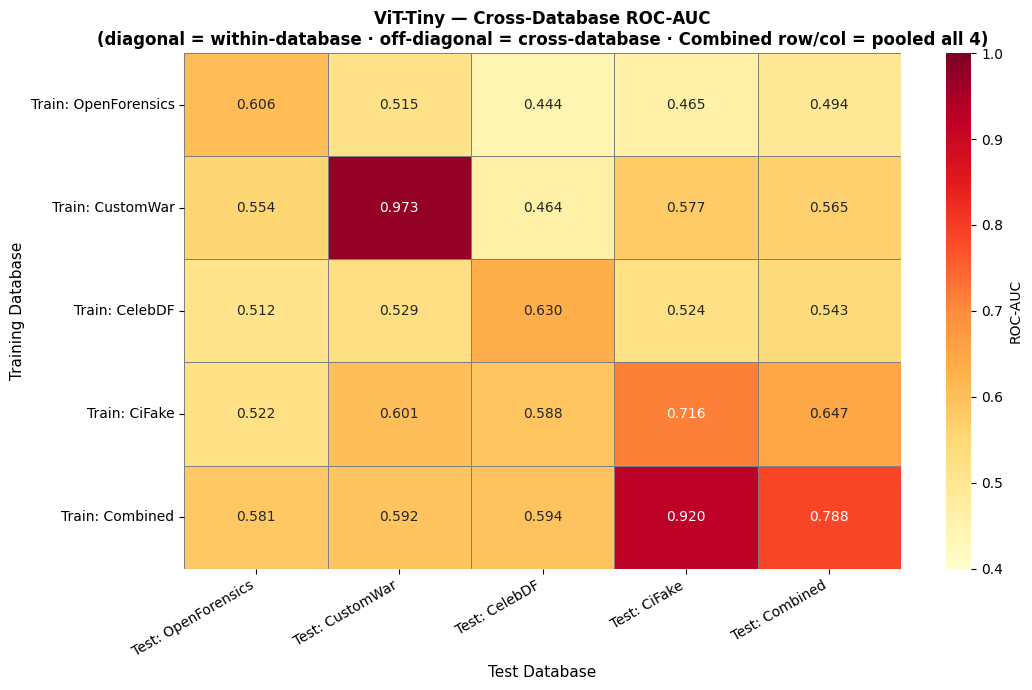

Figure saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/vit/cross_db_roc_auc.png

ROC-AUC Matrix:
                      Test: OpenForensics  Test: CustomWar  Test: CelebDF  Test: CiFake  Test: Combined
Train: OpenForensics             0.605971         0.515216       0.444205      0.464514        0.494196
Train: CustomWar                 0.554301         0.973159       0.464178      0.577219        0.564729
Train: CelebDF                   0.512481         0.528828       0.629737      0.524136        0.543382
Train: CiFake                    0.522090         0.600850       0.587600      0.716130        0.646921
Train: Combined                  0.581174         0.592128       0.593705      0.920473        0.787610



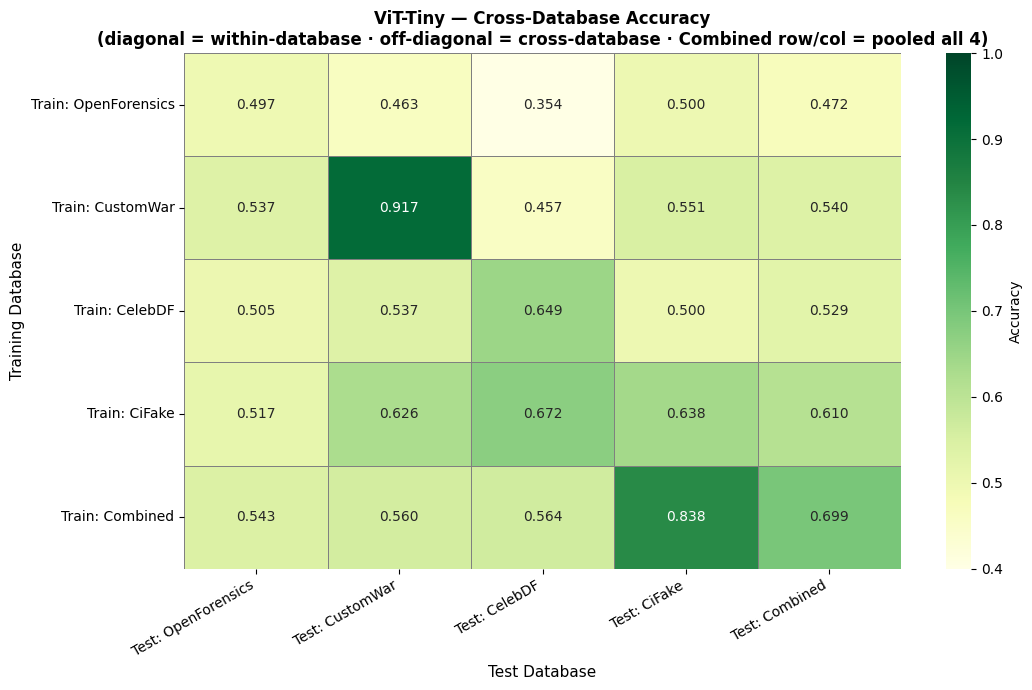

Figure saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/vit/cross_db_accuracy.png

Accuracy Matrix:
                      Test: OpenForensics  Test: CustomWar  Test: CelebDF  Test: CiFake  Test: Combined
Train: OpenForensics             0.496653         0.462771       0.353891       0.49980        0.472078
Train: CustomWar                 0.537001         0.917059       0.456873       0.55075        0.540280
Train: CelebDF                   0.504631         0.537229       0.649164       0.50000        0.528720
Train: CiFake                    0.517011         0.625825       0.672145       0.63755        0.609511
Train: Combined                  0.543145         0.559849       0.564218       0.83780        0.699055



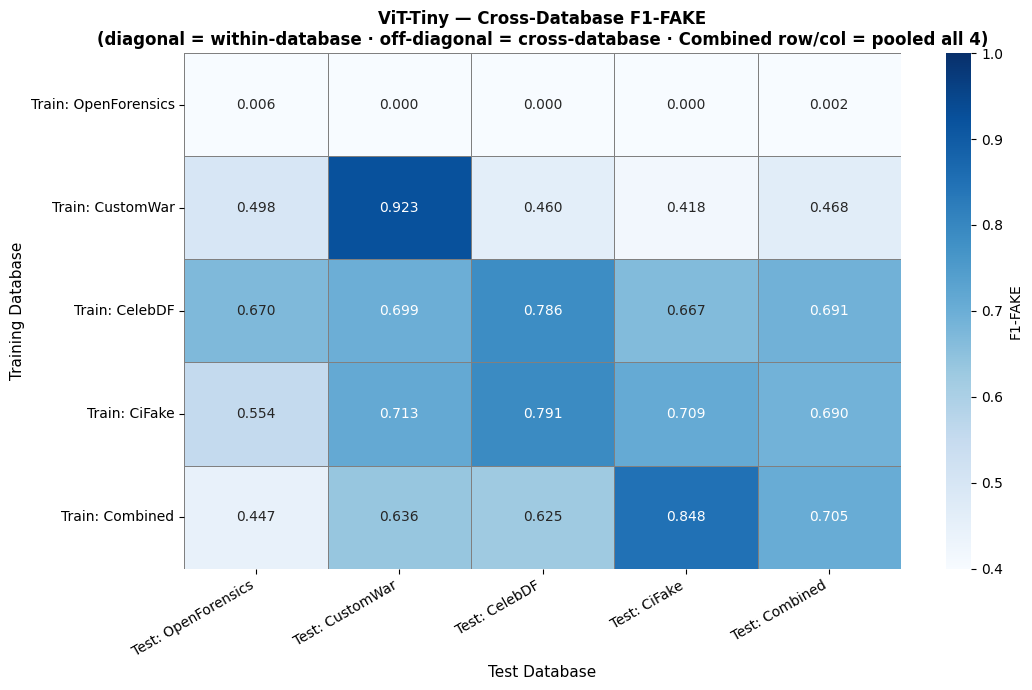

Figure saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/vit/cross_db_f1_fake.png

F1-FAKE Matrix:
                      Test: OpenForensics  Test: CustomWar  Test: CelebDF  Test: CiFake  Test: Combined
Train: OpenForensics             0.006156         0.000000       0.000000      0.000200        0.001753
Train: CustomWar                 0.498061         0.923211       0.460249      0.417655        0.467811
Train: CelebDF                   0.669925         0.698958       0.786094      0.666667        0.691175
Train: CiFake                    0.554135         0.712527       0.791103      0.709401        0.690020
Train: Combined                  0.446567         0.636009       0.624937      0.848468        0.705426



In [11]:
# =================== CELL 10: CROSS-DATABASE RESULTS MATRIX ===================
# 5×5 table matching the experiment design:
#   Rows (train):   4 individual databases + Combined
#   Columns (test): 4 individual databases + Combined

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# All row/column labels in display order
all_db_names = list(DATABASES.keys()) + ['Combined']

for metric_key, metric_label, cmap in [
    ('roc_auc',  'ROC-AUC',  'YlOrRd'),
    ('accuracy', 'Accuracy', 'YlGn'),
    ('f1_fake',  'F1-FAKE',  'Blues'),
]:
    available_rows = [d for d in all_db_names if d in all_results]
    matrix = [
        [all_results[tr].get(te, {}).get(metric_key, float('nan')) for te in all_db_names]
        for tr in available_rows
    ]
    df = pd.DataFrame(
        matrix,
        index=[f'Train: {d}' for d in available_rows],
        columns=[f'Test: {d}' for d in all_db_names]
    )

    fig, ax = plt.subplots(figsize=(11, 7))
    sns.heatmap(
        df.astype(float), annot=True, fmt='.3f',
        cmap=cmap, vmin=0.40, vmax=1.00, ax=ax,
        linewidths=0.5, linecolor='gray',
        cbar_kws={'label': metric_label}
    )
    ax.set_title(
        f'ViT-Tiny — Cross-Database {metric_label}\n'
        '(diagonal = within-database · off-diagonal = cross-database · '
        'Combined row/col = pooled all 4)',
        fontsize=12, fontweight='bold'
    )
    ax.set_ylabel('Training Database', fontsize=11)
    ax.set_xlabel('Test Database', fontsize=11)
    plt.xticks(rotation=30, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    fig_path = os.path.join(MODEL_DIR, f'cross_db_{metric_key}.png')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure saved: {fig_path}')
    print(f'\n{metric_label} Matrix:')
    print(df.to_string())
    print()

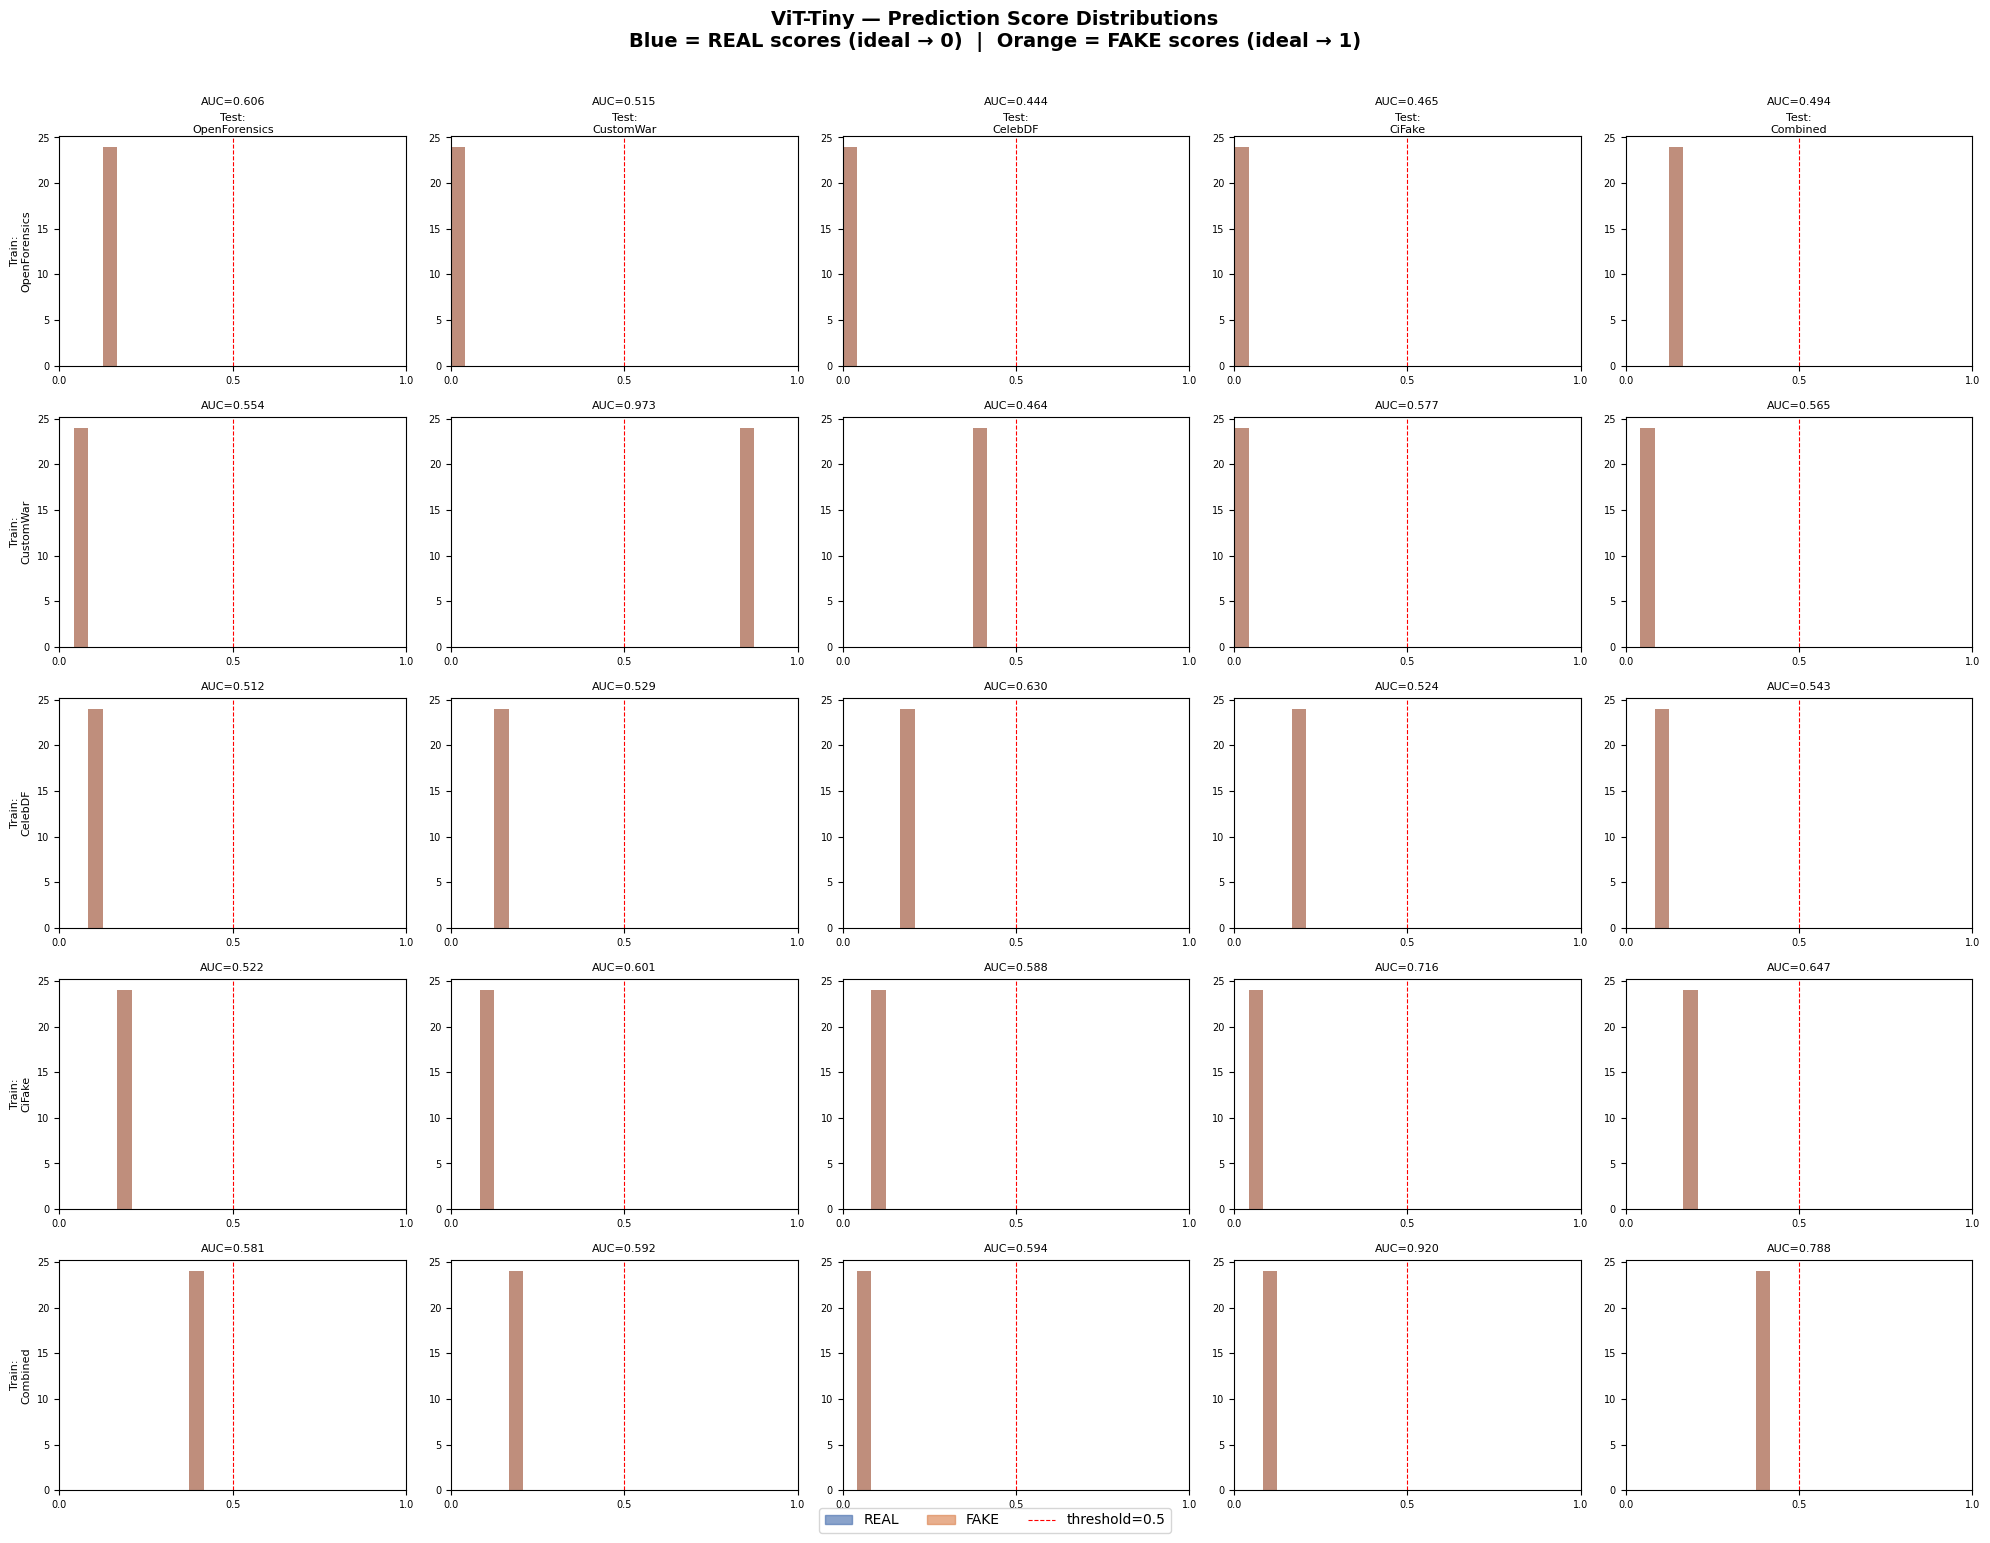

Score histograms saved → /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/vit/score_histograms.png


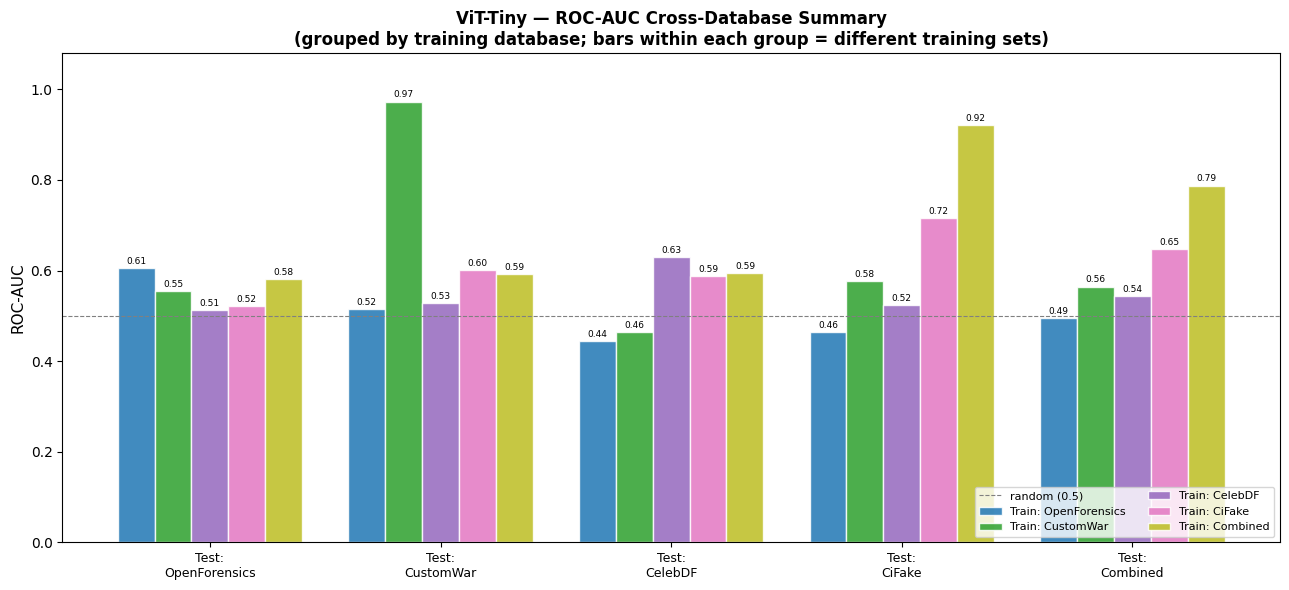

AUC bar chart saved → /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/vit/auc_bar_chart.png
Prediction scores saved → /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/vit/all_predictions.pkl

✅ All visualizations complete. TensorBoard histograms available under Distributions/Histograms tabs.


In [12]:
# =================== CELL 11: PREDICTION SCORE HISTOGRAMS ===================
#
# Two visualizations after all cross-database experiments are done:
#
# Fig 1 — 5×5 grid of overlaid prediction score histograms
#   Each cell = one (train_db → test_db) pair.
#   Blue bars  = REAL image scores  (ideal: clustered near 0)
#   Orange bars = FAKE image scores (ideal: clustered near 1)
#   If both bars overlap in the center → model is uncertain / collapsing.
#
# Fig 2 — Grouped bar chart of ROC-AUC
#   X-axis: test databases (columns of the cross-db table)
#   Bars   : grouped by training database (rows of the cross-db table)
#   Quick read: tall bar in off-diagonal = good cross-db generalization.
#
# These complement TensorBoard (where the same histograms appear under
# the Distributions / Histograms tabs for interactive exploration).
# ─────────────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

all_db_labels = list(DATABASES.keys()) + ['Combined']
n = len(all_db_labels)

MODEL_LABEL = 'ViT-Tiny'
COLORS = {'REAL': '#4C72B0', 'FAKE': '#DD8452'}

# ── Fig 1: Prediction score histogram grid ────────────────────────────────
fig1, axes = plt.subplots(n, n, figsize=(4 * n, 3 * n), squeeze=False)
fig1.suptitle(
    f'{MODEL_LABEL} — Prediction Score Distributions\n'
    'Blue = REAL scores (ideal → 0)  |  Orange = FAKE scores (ideal → 1)',
    fontsize=14, fontweight='bold', y=1.01
)

for r_idx, train_db in enumerate(all_db_labels):
    for c_idx, test_db in enumerate(all_db_labels):
        ax = axes[r_idx][c_idx]
        preds = (all_predictions.get(train_db, {}).get(test_db))
        if preds is None:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                    transform=ax.transAxes, color='gray')
            ax.set_xticks([]); ax.set_yticks([])
        else:
            y_true = preds['y_true']
            y_prob = preds['y_prob']
            real_s = y_prob[y_true == 0]
            fake_s = y_prob[y_true == 1]
            bins = np.linspace(0, 1, 25)
            ax.hist(real_s, bins=bins, alpha=0.65, color=COLORS['REAL'],
                    label='REAL', density=True)
            ax.hist(fake_s, bins=bins, alpha=0.65, color=COLORS['FAKE'],
                    label='FAKE', density=True)
            auc = all_results.get(train_db, {}).get(test_db, {}).get('roc_auc', float('nan'))
            ax.set_title(f'AUC={auc:.3f}', fontsize=8)
            ax.axvline(0.5, color='red', linewidth=0.8, linestyle='--')
            ax.set_xlim(0, 1)
            ax.set_xticks([0, 0.5, 1])
            ax.tick_params(labelsize=7)

        if r_idx == 0:
            ax.set_xlabel(f'Test:\n{test_db}', fontsize=8, labelpad=2)
            ax.xaxis.set_label_position('top')
        if c_idx == 0:
            ax.set_ylabel(f'Train:\n{train_db}', fontsize=8, rotation=90, labelpad=4)

real_patch  = mpatches.Patch(color=COLORS['REAL'],   alpha=0.65, label='REAL')
fake_patch  = mpatches.Patch(color=COLORS['FAKE'],   alpha=0.65, label='FAKE')
thresh_line = plt.Line2D([0], [0], color='red', linestyle='--', linewidth=0.8,
                          label='threshold=0.5')
fig1.legend(handles=[real_patch, fake_patch, thresh_line],
            loc='lower center', ncol=3, fontsize=10,
            bbox_to_anchor=(0.5, -0.01))
plt.tight_layout()
hist_path = os.path.join(MODEL_DIR, 'score_histograms.png')
plt.savefig(hist_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Score histograms saved → {hist_path}')


# ── Fig 2: ROC-AUC grouped bar chart ─────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(13, 6))

bar_width = 0.8 / n
x = np.arange(n)
cmap = plt.get_cmap('tab10')

for i, train_db in enumerate(all_db_labels):
    auc_vals = [
        all_results.get(train_db, {}).get(test_db, {}).get('roc_auc', float('nan'))
        for test_db in all_db_labels
    ]
    bars = ax2.bar(
        x + i * bar_width, auc_vals, bar_width,
        label=f'Train: {train_db}',
        color=cmap(i / n), alpha=0.85, edgecolor='white'
    )
    for bar, val in zip(bars, auc_vals):
        if not np.isnan(val):
            ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                     f'{val:.2f}', ha='center', va='bottom', fontsize=6.5)

ax2.set_xticks(x + bar_width * (n - 1) / 2)
ax2.set_xticklabels([f'Test:\n{d}' for d in all_db_labels], fontsize=9)
ax2.set_ylabel('ROC-AUC', fontsize=11)
ax2.set_ylim(0, 1.08)
ax2.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='random (0.5)')
ax2.set_title(
    f'{MODEL_LABEL} — ROC-AUC Cross-Database Summary\n'
    '(grouped by training database; bars within each group = different training sets)',
    fontsize=12, fontweight='bold'
)
ax2.legend(loc='lower right', fontsize=8, ncol=2)
plt.tight_layout()
bar_path = os.path.join(MODEL_DIR, 'auc_bar_chart.png')
plt.savefig(bar_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'AUC bar chart saved → {bar_path}')


# ── Save all_predictions alongside all_results ────────────────────────────
import pickle
pred_path = os.path.join(MODEL_DIR, 'all_predictions.pkl')
with open(pred_path, 'wb') as f:
    pickle.dump(all_predictions, f)
print(f'Prediction scores saved → {pred_path}')
print('\n✅ All visualizations complete. TensorBoard histograms available under Distributions/Histograms tabs.')

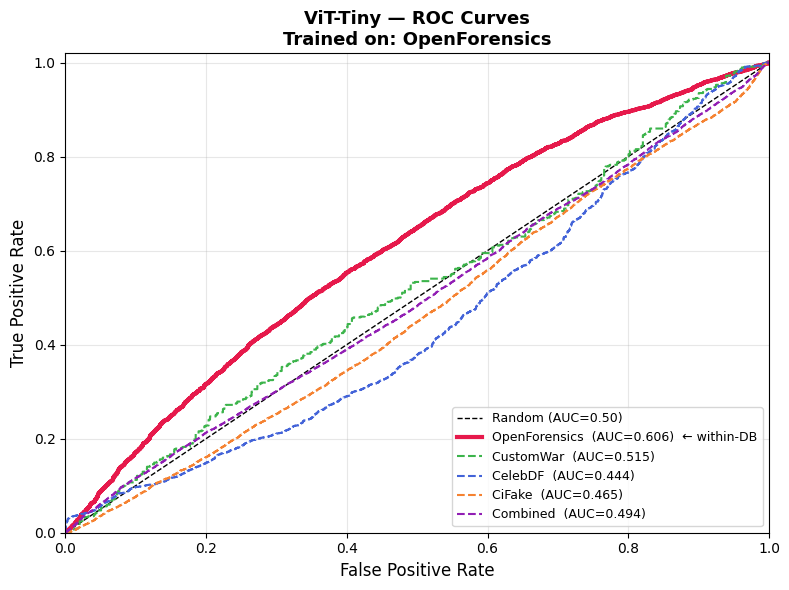

Saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/vit/roc_curves_OpenForensics.png



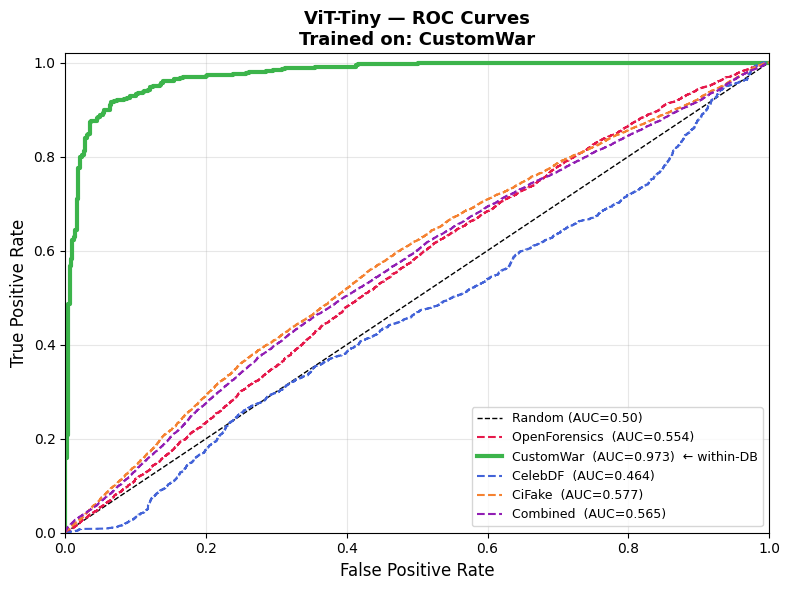

Saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/vit/roc_curves_CustomWar.png



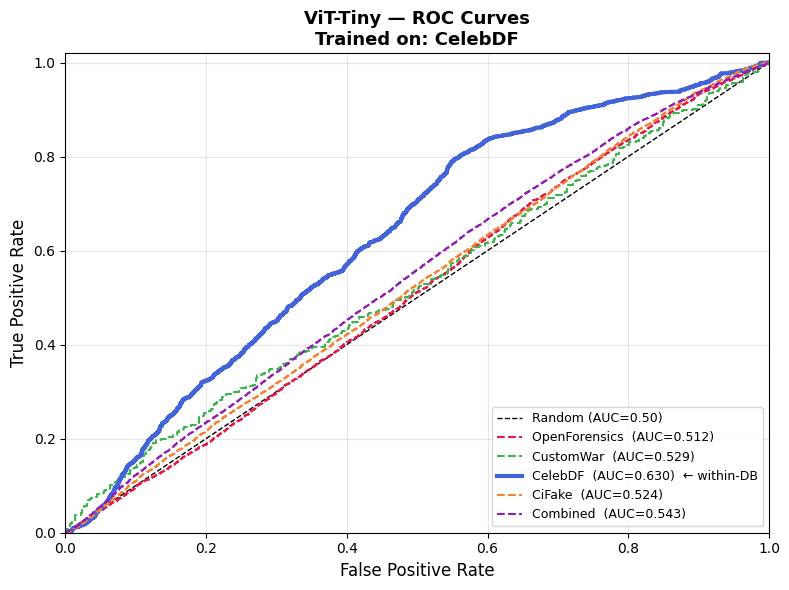

Saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/vit/roc_curves_CelebDF.png



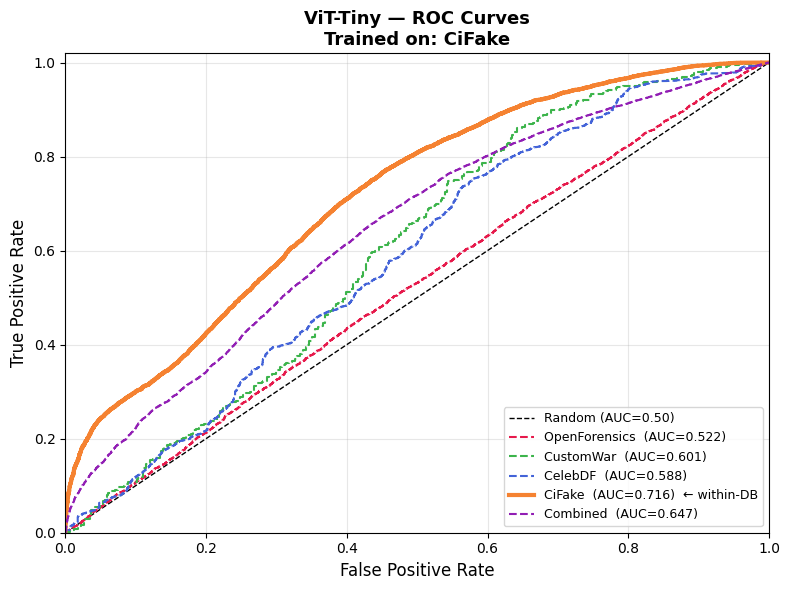

Saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/vit/roc_curves_CiFake.png



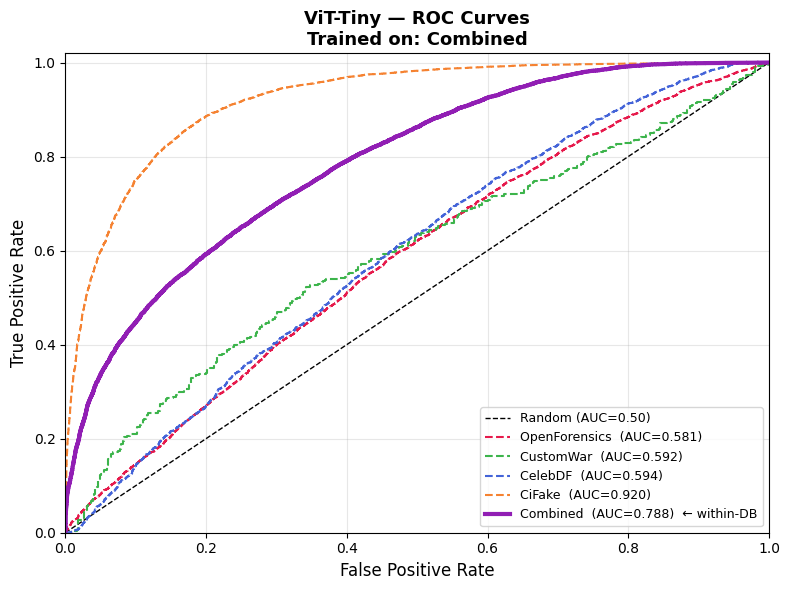

Saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/vit/roc_curves_Combined.png



In [13]:
# =================== CELL 12: ROC CURVES ===================
# One figure per training target (5 total).
# Each figure overlays 5 ROC curves — one per test database.
# Within-DB curve is highlighted with a thicker solid line.
# ──────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve
import os

all_train_names = list(DATABASES.keys()) + ['Combined']
TEST_COLORS = {
    db: c for db, c in zip(
        all_train_names,
        ['#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4']
    )
}

for train_target in all_train_names:
    if train_target not in all_predictions:
        print(f'[SKIP] No predictions for train={train_target}')
        continue

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.50)')

    for test_target in all_train_names:
        if test_target not in all_predictions.get(train_target, {}):
            continue
        y_true = np.array(all_predictions[train_target][test_target]['y_true'])
        y_prob = np.array(all_predictions[train_target][test_target]['y_prob'])
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc_val   = all_results[train_target][test_target]['roc_auc']
        is_within = (train_target == test_target)
        label     = f'{test_target}  (AUC={auc_val:.3f})'
        if is_within:
            label += '  ← within-DB'
        ax.plot(fpr, tpr,
                color=TEST_COLORS.get(test_target, 'gray'),
                lw=3.0 if is_within else 1.5,
                ls='-'  if is_within else '--',
                label=label)

    ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.02])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate',  fontsize=12)
    ax.set_title(f'ViT-Tiny — ROC Curves\nTrained on: {train_target}',
                 fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig_path = os.path.join(MODEL_DIR, f'roc_curves_{train_target}.png')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fig_path}')
    print()

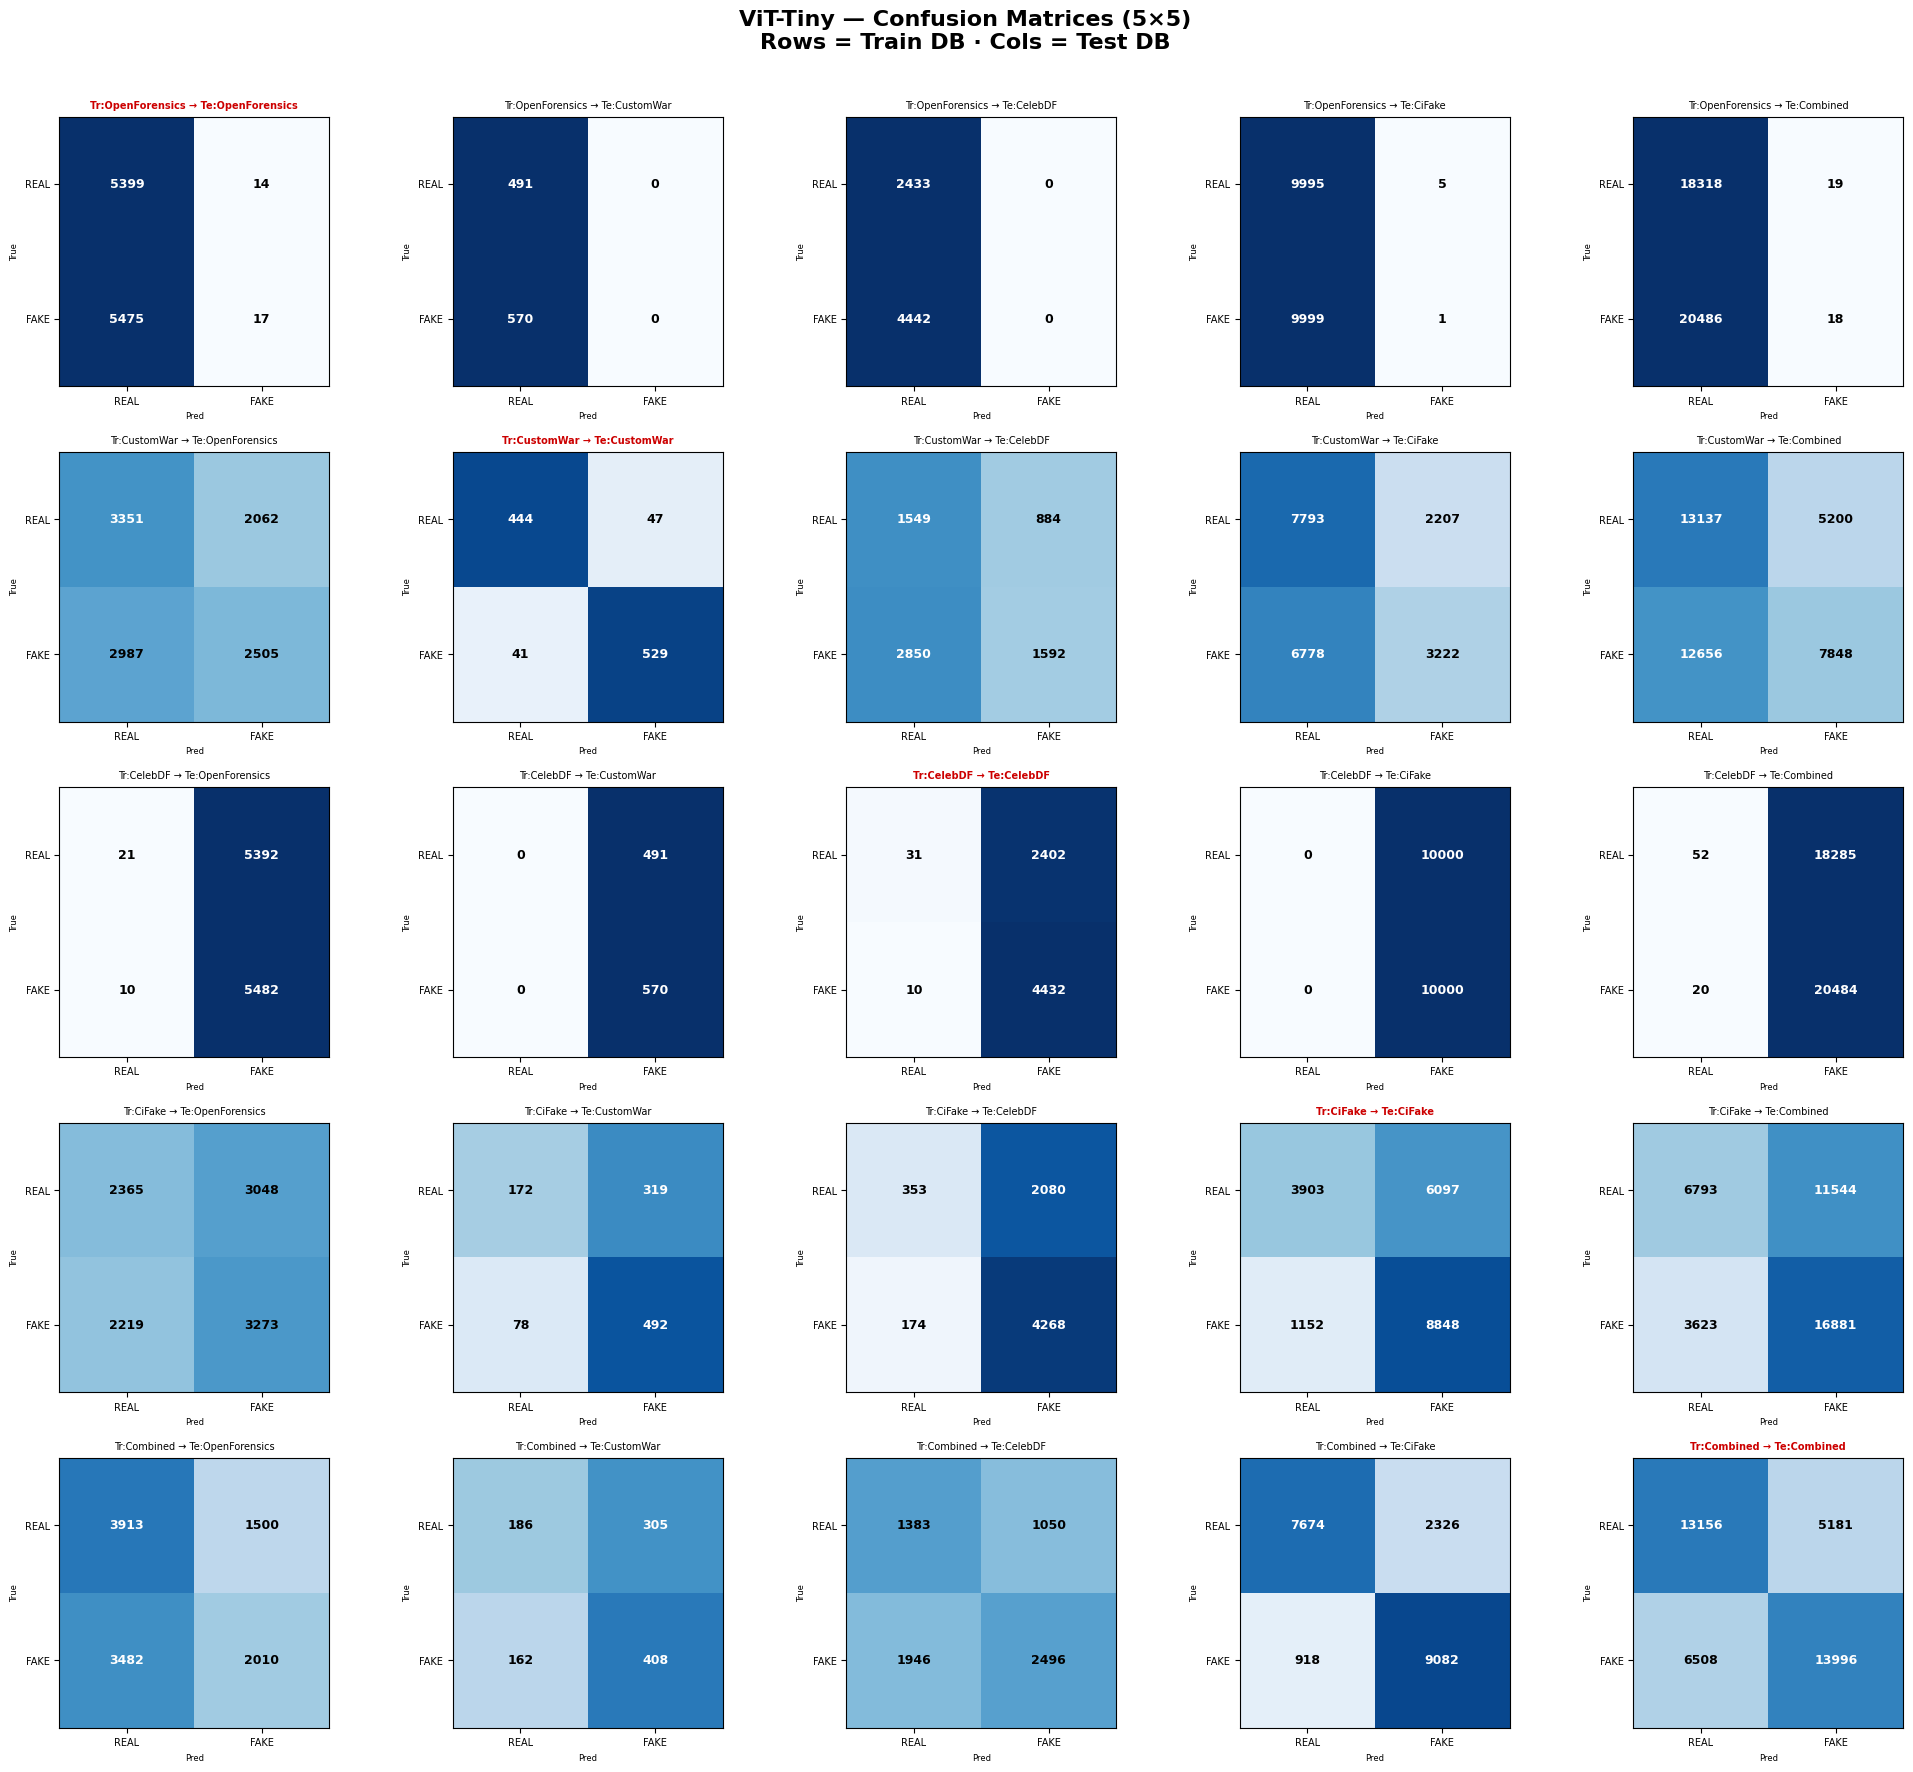

Saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/vit/confusion_matrices_5x5.png


In [14]:
# =================== CELL 13: CONFUSION MATRICES (5×5 GRID) ===================
# One confusion matrix per (train, test) pair — 25 total.
# Diagonal = within-DB (red title). Colour encodes normalised row accuracy.
# ──────────────────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import os

all_train_names = list(DATABASES.keys()) + ['Combined']
n = len(all_train_names)

fig, axes = plt.subplots(n, n, figsize=(4 * n, 3.5 * n))
fig.suptitle('ViT-Tiny — Confusion Matrices (5×5)\nRows = Train DB · Cols = Test DB',
             fontsize=16, fontweight='bold', y=1.01)

for r, train_target in enumerate(all_train_names):
    for c, test_target in enumerate(all_train_names):
        ax = axes[r][c]
        if (train_target not in all_predictions or
                test_target not in all_predictions.get(train_target, {})):
            ax.axis('off')
            ax.set_title(f'Tr:{train_target}\nTe:{test_target}', fontsize=7)
            continue

        y_true = np.array(all_predictions[train_target][test_target]['y_true'])
        y_pred = (np.array(all_predictions[train_target][test_target]['y_prob']) >=
                  all_results[train_target][test_target].get('threshold', 0.5)).astype(int)
        cm      = confusion_matrix(y_true, y_pred)
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

        ax.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
        ax.set_xticks([0, 1]); ax.set_xticklabels(['REAL', 'FAKE'], fontsize=7)
        ax.set_yticks([0, 1]); ax.set_yticklabels(['REAL', 'FAKE'], fontsize=7)
        for i in range(2):
            for j in range(2):
                color = 'white' if cm_norm[i, j] > 0.6 else 'black'
                ax.text(j, i, str(cm[i, j]),
                        ha='center', va='center',
                        fontsize=9, fontweight='bold', color=color)
        is_within = (train_target == test_target)
        ax.set_title(f'Tr:{train_target} → Te:{test_target}',
                     fontsize=7,
                     color='#cc0000' if is_within else 'black',
                     fontweight='bold' if is_within else 'normal')
        ax.set_ylabel('True', fontsize=6); ax.set_xlabel('Pred', fontsize=6)

plt.tight_layout()
cm_path = os.path.join(MODEL_DIR, 'confusion_matrices_5x5.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {cm_path}')

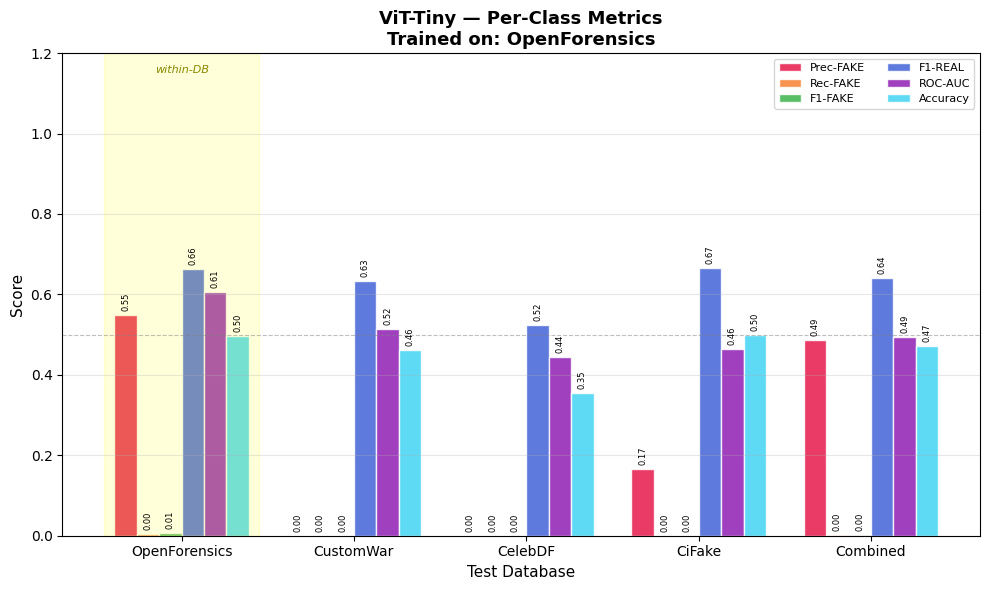

Saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/vit/per_class_metrics_OpenForensics.png



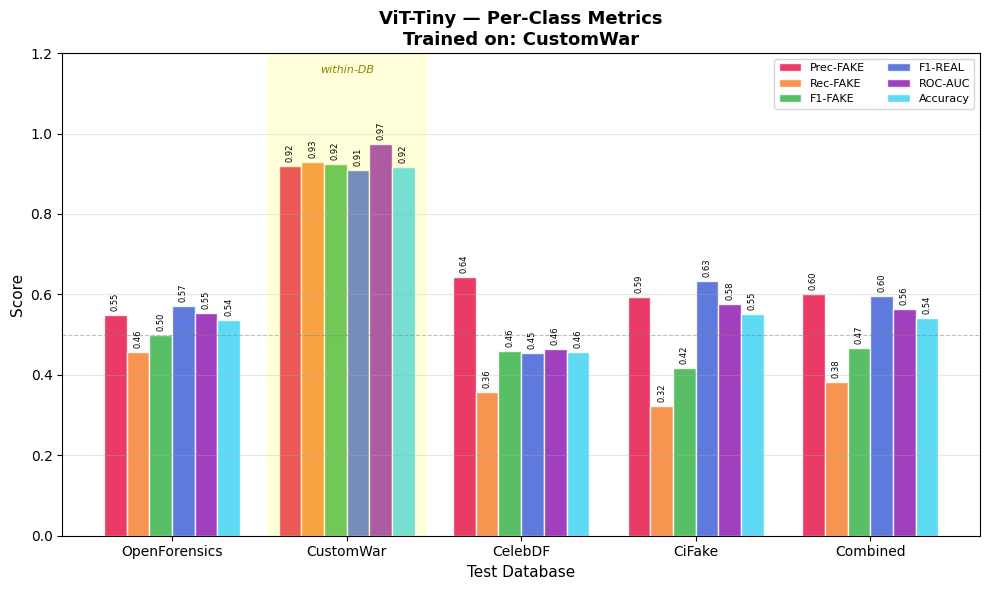

Saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/vit/per_class_metrics_CustomWar.png



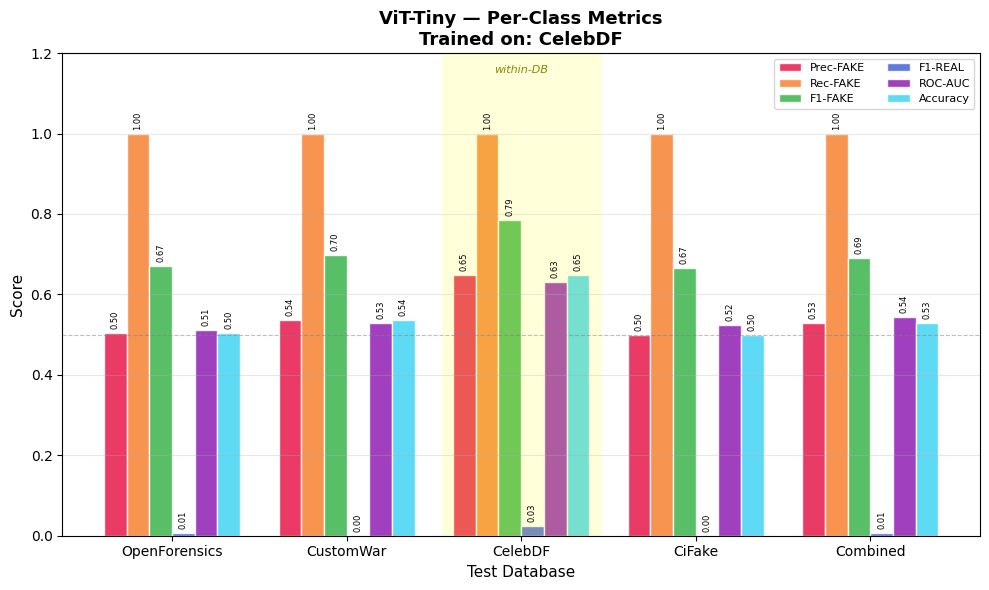

Saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/vit/per_class_metrics_CelebDF.png



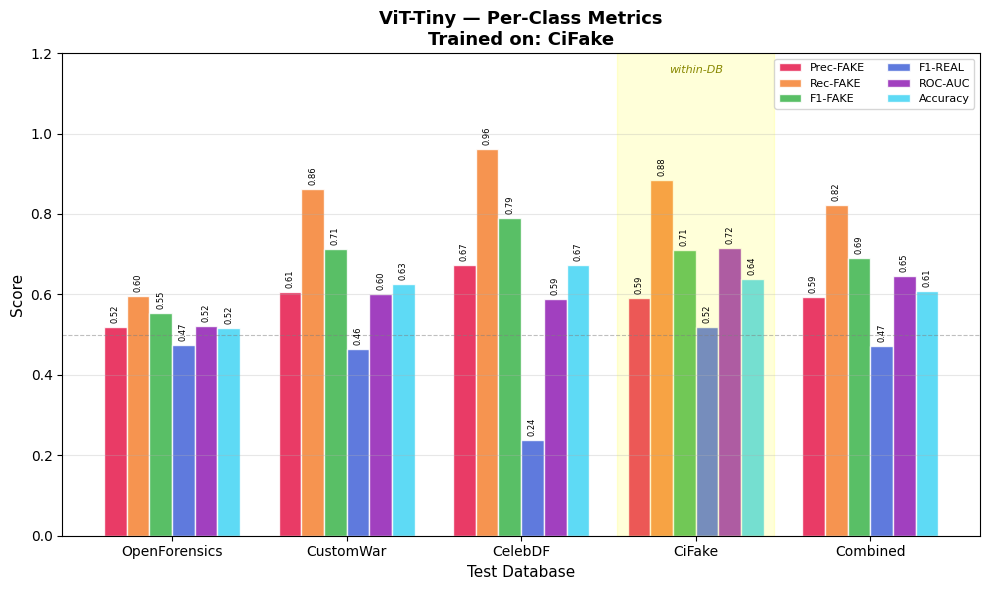

Saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/vit/per_class_metrics_CiFake.png



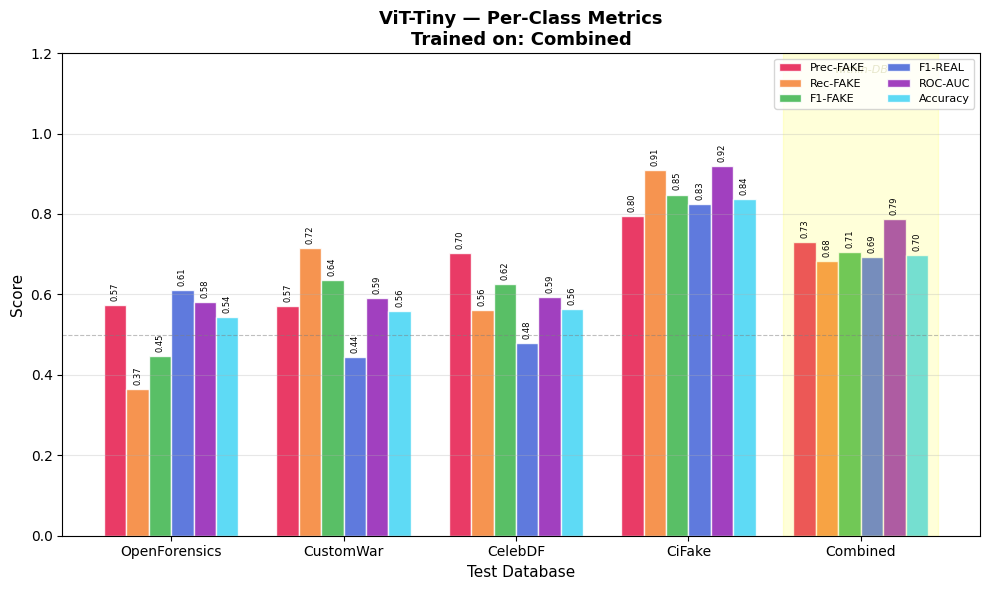

Saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/vit/per_class_metrics_Combined.png



In [15]:
# =================== CELL 14: PER-CLASS METRICS BAR CHART ===================
# For each training target: grouped bars showing all key metrics
# across all test databases. Within-DB group highlighted in yellow.
# ──────────────────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import numpy as np
import os

all_train_names = list(DATABASES.keys()) + ['Combined']

METRICS = [
    ('precision_fake', 'Prec-FAKE',  '#e6194b'),
    ('recall_fake',    'Rec-FAKE',   '#f58231'),
    ('f1_fake',        'F1-FAKE',    '#3cb44b'),
    ('f1_real',        'F1-REAL',    '#4363d8'),
    ('roc_auc',        'ROC-AUC',    '#911eb4'),
    ('accuracy',       'Accuracy',   '#42d4f4'),
]

for train_target in all_train_names:
    if train_target not in all_results:
        continue
    test_dbs  = [t for t in all_train_names if t in all_results[train_target]]
    n_tests   = len(test_dbs)
    n_metrics = len(METRICS)
    x         = np.arange(n_tests)
    bar_w     = 0.13
    offsets   = np.linspace(-(n_metrics - 1) / 2, (n_metrics - 1) / 2, n_metrics) * bar_w

    fig, ax = plt.subplots(figsize=(max(10, n_tests * 2), 6))

    for i, (key, label, color) in enumerate(METRICS):
        values = [all_results[train_target][t].get(key, float('nan')) for t in test_dbs]
        bars   = ax.bar(x + offsets[i], values, bar_w,
                        label=label, color=color, alpha=0.85, edgecolor='white')
        for bar, val in zip(bars, values):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.01,
                        f'{val:.2f}', ha='center', va='bottom',
                        fontsize=6, rotation=90)

    ax.set_xticks(x); ax.set_xticklabels(test_dbs, fontsize=10)
    ax.set_ylim(0, 1.20)
    ax.set_ylabel('Score', fontsize=11); ax.set_xlabel('Test Database', fontsize=11)
    ax.set_title(f'ViT-Tiny — Per-Class Metrics\nTrained on: {train_target}',
                 fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8, ncol=2)
    ax.axhline(0.5, color='gray', lw=0.8, ls='--', alpha=0.5)
    ax.grid(axis='y', alpha=0.3)
    if train_target in test_dbs:
        idx = test_dbs.index(train_target)
        ax.axvspan(idx - 0.45, idx + 0.45, color='yellow', alpha=0.15)
        ax.text(idx, 1.15, 'within-DB', ha='center', fontsize=8,
                color='#888800', fontstyle='italic')

    plt.tight_layout()
    fig_path = os.path.join(MODEL_DIR, f'per_class_metrics_{train_target}.png')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fig_path}')
    print()

In [16]:
# =================== FINAL GOOGLE DRIVE SYNC ===================
# Syncs ALL models, results (.pkl), and ALL visualisation PNGs
# to Google Drive.  Runs after visualisations so every PNG is included.
# ────────────────────────────────────────────────────────────────

import subprocess

gdrive_dest  = 'gdrive:deepfake_image_project/models/RealEyes_experiment/vit'
print(f'Syncing {MODEL_DIR}')
print(f'     to {gdrive_dest} ...')

result = subprocess.run(
    ['rclone', 'sync', MODEL_DIR, gdrive_dest, '--progress', '--stats-one-line'],
    capture_output=False, text=True
)
if result.returncode == 0:
    print(f'\nGoogle Drive sync complete.')
    print(f'  All models, results, and visualisations are now on Drive.')
else:
    print(f'\nWARNING: rclone sync failed (exit {result.returncode}).')
    print(f'  Files are safe locally at {MODEL_DIR}')

Syncing /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/vit
     to gdrive:deepfake_image_project/models/RealEyes_experiment/vit ...
586.989 KiB / 1.906 MiB, 30%, 0 B/s, ETA - (xfr#0/16)586.989 KiB / 1.906 MiB, 30%, 0 B/s, ETA - (xfr#0/16)860.988 KiB / 1.906 MiB, 44%, 586.914 KiB/s, ETA 1s (xfr#4/16)933.862 KiB / 1.906 MiB, 48%, 586.914 KiB/s, ETA 1s (xfr#4/16)1.188 MiB / 1.906 MiB, 62%, 466.893 KiB/s, ETA 1s (xfr#7/16)1.333 MiB / 1.906 MiB, 70%, 454.930 KiB/s, ETA 1s (xfr#8/16)1.760 MiB / 1.906 MiB, 92%, 454.930 KiB/s, ETA 0s (xfr#11/16)1.906 MiB / 1.906 MiB, 100%, 487.829 KiB/s, ETA 0s1.906 MiB / 1.906 MiB, 100%, 487.829 KiB/s, ETA 0s1.906 MiB / 1.906 MiB, 100%, 487.829 KiB/s, ETA 0s

Google Drive sync complete.
  All models, results, and visualisations are now on Drive.


In [17]:
# =================== CELL 12: TENSORBOARD LAUNCH INSTRUCTIONS ===================

print('━' * 60)
print('  📊  TENSORBOARD DASHBOARD')
print('━' * 60)
print()
print('1️⃣  On the SERVER terminal, run:')
print(f'   tensorboard --logdir {TB_LOG_ROOT} --port 6006 --bind_all')
print()
print('2️⃣  On your LOCAL machine, open an SSH tunnel:')
print('   ssh -L 6006:localhost:6006 <your_user>@<server_ip>')
print()
print('3️⃣  Open in browser:  http://localhost:6006')
print()
print('In TensorBoard SCALARS tab, filter by "vit" to see:')
print('  • Per-epoch loss / accuracy / auc for each training database')
print('  • ViT vs EfficientNet vs CNN-SRM convergence comparison')
print('    (all models log to the same TB_LOG_ROOT — toggle models in the UI)')
print()
print('Expected behavior for ViT:')
print('  • Larger databases (OpenForensics, CelebDF) → faster convergence')
print('  • Small databases (CustomWar ~7k) → slower convergence or higher val loss')
print('  • This gap vs EfficientNetB0 is itself a research finding.')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📊  TENSORBOARD DASHBOARD
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1️⃣  On the SERVER terminal, run:
   tensorboard --logdir /home/sceuser/RealEyes/tensorboard_logs --port 6006 --bind_all

2️⃣  On your LOCAL machine, open an SSH tunnel:
   ssh -L 6006:localhost:6006 <your_user>@<server_ip>

3️⃣  Open in browser:  http://localhost:6006

In TensorBoard SCALARS tab, filter by "vit" to see:
  • Per-epoch loss / accuracy / auc for each training database
  • ViT vs EfficientNet vs CNN-SRM convergence comparison
    (all models log to the same TB_LOG_ROOT — toggle models in the UI)

Expected behavior for ViT:
  • Larger databases (OpenForensics, CelebDF) → faster convergence
  • Small databases (CustomWar ~7k) → slower convergence or higher val loss
  • This gap vs EfficientNetB0 is itself a research finding.
